### Final Project: Machine Learning and Deep Learning
# GoLocker Package Dwell Time

**Title:** Predicting Parcel Pickup Time in Smart Locker Systems with Multiclass Classification

**Research Question:** *How accurately can package dwell time in a locker be predicted using ML models?*



Jovita Beržinytė - 185905

Violett Korbély - 186626

Win Pa Pa Swe - 186421

# 1. `Data Cleaning`

---
### 1.1 Data Loading

In [ ]:
pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 10.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.cm as cm
import seaborn as sns

from math import radians, sin, cos, sqrt, atan2
from rapidfuzz import fuzz
from sklearn.neighbors import BallTree
import re
import holidays
import time

import os
import random
os.environ['PYTHONHASHSEED'] = '42'
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Plot style
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
})

PALETTE = sns.color_palette('tab10')
pd.set_option('display.max_columns', None)

# Constants
EARTH_RADIUS_KM = 6371.0
EARTH_RADIUS_M = 6371000
RADIUS_METERS = 300

In [ ]:
# Load data
locker_file_git_path = "https://raw.githubusercontent.com/JovitaBer/ML_2026_Practice/main/LockerNYC_Reservations_20260412.csv"
locker_location_git_path = "https://raw.githubusercontent.com/JovitaBer/ML_2026_Practice/main/LockerNYC_Locations_-_Pilot_Program_20260429.csv"

df = pd.read_csv(locker_file_git_path, sep=",")
df_loc = pd.read_csv(locker_location_git_path, sep=",")

In [ ]:
# Standardize location column names

# Rename columns to consistent snake_case format
df_loc = df_loc.drop_duplicates(subset=['Address'])

# Keep only relevant columns with standardized names
relevant_cols = ["Locker_Name", "Locker_Size", "Address", "Location", "Latitude", "Longitude"]
df_loc = df_loc[["Locker_Name", "Locker Size", "Address", "Location", "Latitude", "Longitude"]]
df_loc = df_loc.rename(columns={
    'Locker_Name': 'locker_name',
    'Locker Size': 'locker_size',
    'Address': 'address',
    'Location': 'location',
    'Latitude': 'latitude',
    'Longitude': 'longitude'
})

df = df.rename(columns={
    'longitude': 'longitude',
    'Locker Name': 'locker_name',
    'Address': 'address',
    'Latitude': 'latitude',
    'Longitude': 'longitude'
})

In [ ]:
def to_snake_case(name):
    """Convert various naming conventions to snake_case."""
    # Handle PascalCase/camelCase (e.g., "Created Date" -> "created_date")
    name = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    name = re.sub('([a-z0-9])([A-Z])', r'\1_\2', name)
    # Replace spaces with single underscore
    name = re.sub(r'\s+', '_', name)
    # Replace hyphens with underscore
    name = name.replace('-', '_')
    # Remove any special characters except underscores
    name = re.sub(r'[^\w\s]', '', name)
    # Replace multiple underscores with single underscore
    name = re.sub(r'_+', '_', name)
    # Remove leading/trailing underscores
    name = name.strip('_')
    # Convert to lowercase
    return name.lower()

df.columns = [to_snake_case(col) for col in df.columns]
df_loc.columns = [to_snake_case(col) for col in df_loc.columns]

In [ ]:
df_loc = df_loc.drop_duplicates(subset=['address'])

# Keep only relevant columns for merging
relevant_cols = ["locker_name", "locker_size", "address", "location", "latitude", "longitude"]
df_loc = df_loc[relevant_cols]

In [ ]:
def clean_text(x):
    """Standardize text: lowercase, remove punctuation, normalize abbreviations."""
    if pd.isna(x):
        return ""

    x = x.lower()

    # Remove text in parentheses
    x = re.sub(r"\(.*?\)", "", x)

    # Standardize abbreviations
    x = x.replace("street", "st")
    x = x.replace("avenue", "ave")
    x = x.replace("east", "e")
    x = x.replace("west", "w")

    # Remove punctuation
    x = re.sub(r"[^a-z0-9\s]", "", x)

    # Collapse whitespace
    x = re.sub(r"\s+", " ", x).strip()

    return x

# Apply cleaning
df_loc["locker_name"] = df_loc["locker_name"].apply(clean_text)
df_loc["address"] = df_loc["address"].apply(clean_text)

df["locker_name"] = df["locker_name"].apply(clean_text)
df["address"] = df["address"].apply(clean_text)

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in kilometers."""
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return EARTH_RADIUS_KM * c

# Convert coordinates to radians for BallTree
coords_df = np.radians(df[['latitude', 'longitude']])
coords_loc = np.radians(df_loc[['latitude', 'longitude']])

# Build BallTree and find candidates within radius
tree = BallTree(coords_loc, metric='haversine')
radius_radians = RADIUS_METERS / EARTH_RADIUS_M
candidate_indices = tree.query_radius(coords_df, r=radius_radians)

# Fuzzy matching with weighted scoring
matches = []
for i, candidates in enumerate(candidate_indices):
    row_df = df.iloc[i]
    best_score = -1
    best_match = None

    for j in candidates:
        row_loc = df_loc.iloc[j]

        # Fuzzy scores
        name_score = fuzz.token_sort_ratio(
            row_df["locker_name"],
            row_loc["locker_name"]
        )

        addr_score = fuzz.token_sort_ratio(
            row_df["address"],
            row_loc["address"]
        )

        # Weighted total
        total_score = (
            0.4 * name_score +
            0.6 * addr_score
        )

        if total_score > best_score:
            best_score = total_score
            best_match = {
                "df_index": i,
                "df_loc_index": j,
                "name_score": name_score,
                "addr_score": addr_score,
                "total_score": total_score
            }

    if best_match:
        matches.append(best_match)

# Filter matches by score threshold and merge
matches_df = pd.DataFrame(matches)
matches_df = matches_df[
    matches_df["total_score"] >= 50]

df = df.reset_index(drop=True)
df["df_index"] = df.index
df_loc = df_loc.reset_index(drop=True)
df_loc["df_loc_index"] = df_loc.index

df_final = (
    df.merge(matches_df[["df_index", "df_loc_index"]], on="df_index", how="left")
      .merge(df_loc.drop(columns=["locker_name", "address"]), on="df_loc_index", how="left", suffixes=("", "_master"))
)

In [ ]:
# Manual mapping for unmatched locations
# key = cleaned locker name + cleaned address

manual_map = {
    # (cleaned_locker_name, cleaned_address): {"locker_size": value, "location": value}
    ("golockerfarm country of astoria", "3715 31st ave astoria ny 11103"): {"locker_size": "S", "location": "Outdoor"},
    ("golockerastoria central parking", "3157 31st st astoria ny 11106"): {"locker_size": "S", "location": "Indoor"},
    ("golockerideal", "2036 bedford ave brooklyn ny 11226"): {"locker_size": "M", "location": "Outdoor"},
    ("golockerideal", "830 lafayette ave brooklyn ny 11221"): {"locker_size": "S", "location": "Outdoor"},
    ("golockerlavanderia express iv", "287 graham ave brooklyn ny 11211"): {"locker_size": "S", "location": "Indoor"},
    ("golockersherman parking ridgewood", "1870 troutman st ridgewood ny 11385"): {"locker_size": "S", "location": "Indoor"},
    ("golockerkey foodgravesend", "319 kings hwy brooklyn ny 11223"): {"locker_size": "M", "location": "Outdoor"},
    ("golockermobicompu repair", "279 smith st brooklyn ny 11231"): {"locker_size": "S", "location": "Indoor"},
    ("golockeramericas food basket", "1380 rockaway pkwy brooklyn ny 11236"): {"locker_size": "S", "location": "Outdoor"},
    ("golockerdowntown natural market", "1701 church ave brooklyn ny 11226"): {"locker_size": "S", "location": "Outdoor"},
    ("golockerbushwich organic deli 2", "241 taaffe pl brooklyn ny 11205"): {"locker_size": "S", "location": "Outdoor"},
    ("golockerbushwich organic deli 2", "600 w 161 st new york ny 10032"): {"locker_size": "S", "location": "Outdoor"},
    ("golockerbushwich organic deli 2", "186 dekalb ave brooklyn ny 11205"): {"locker_size": "S", "location": "Indoor"},
    ("golockerbushwich organic deli 2", "7280 wyckoff ave brooklyn ny 11237"): {"locker_size": "S", "location": "Outdoor"},
    ("golockerbushwich organic deli 2", "8319 3rd ave brooklyn ny 11209"): {"locker_size": "S", "location": "Indoor"},
    ("golockerbushwich organic deli 2", "445 albee square w brooklyn ny 11201"): {"locker_size": "S", "location": "Indoor"},
    ("golockerca grocery", "4806 46th st woodside ny 11377"): {"locker_size": "L", "location": "Outdoor"},
    ("golockerideal", "1086 brooklyn ave brooklyn ny 11203"): {"locker_size": "M", "location": "Outdoor"},
    ("golockerone stop blue printing", "80 mcguiness blvd brooklyn ny 11222"): {"locker_size": "S", "location": "Indoor"},
    ("golockerbushwick deli corp", "1486 bushwick ave brooklyn ny 11207"): {"locker_size": "S", "location": "Outdoor"},
    ("bright mart laundry bushwick", "1065 broadway brooklyn ny 11221"): {"locker_size": "S", "location": "Indoor"},
    ("upper e side", "134 12 e 62nd st new york ny 10065"): {"locker_size": "S", "location": "Outdoor"},
}

# Apply manual mapping
df_final["clean_name_for_manual"] = df_final["locker_name"].apply(clean_text)
df_final["clean_address_for_manual"] = df_final["address"].apply(clean_text)

for (name, addr), vals in manual_map.items():
    mask = (df_final["clean_name_for_manual"] == clean_text(name)) & (df_final["clean_address_for_manual"] == clean_text(addr))
    for col, value in vals.items():
        df_final.loc[mask, col] = value

In [ ]:
# Drop temporary columns
df_final = df_final.drop(columns=["clean_name_for_manual", "clean_address_for_manual", "latitude_master", "longitude_master"])
df = df_final.copy()

In [ ]:
# Joining the location on address is still not accurate
len(df.loc[df["locker_size"].isna()])

0

---
### 1.2 Data Quality Checks

In [ ]:
# Schema overview
print('='*60)
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
print('='*60)
df.info()

Rows: 27,931  |  Columns: 32
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27931 entries, 0 to 27930
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   type                                   27931 non-null  object 
 1   status                                 27931 non-null  object 
 2   created_date                           27931 non-null  object 
 3   delivered                              27931 non-null  bool   
 4   delivery_date                          27895 non-null  object 
 5   received                               27931 non-null  bool   
 6   receive_date                           27315 non-null  object 
 7   withdrawn                              27931 non-null  bool   
 8   withdraw_date                          27899 non-null  object 
 9   expired                                27931 non-null  bool   
 10  expire_date                            27

Columns with missing values:
                                       missing_count  missing_pct
send_duration                                  27390    98.063084
collect_duration                               26662    95.456661
delivery_duration                               1774     6.351366
bin                                             1458     5.220006
bbl                                             1458     5.220006
council_district                                1437     5.144821
census_tract_2020                               1437     5.144821
neighborhood_tabulation_area_nta_2020           1437     5.144821
community_board                                 1437     5.144821
pickup_duration                                 1308     4.682969
df_loc_index                                     632     2.262719
receive_date                                     616     2.205435
locker_box_door                                   38     0.136050
delivery_date                                  

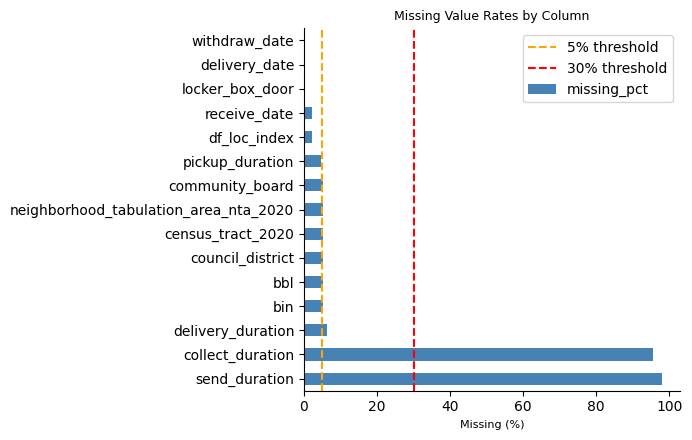

In [ ]:
# Missing value report
missing = (
    df.isnull()
    .sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda x: x['missing_count'] / len(df) * 100)
    .sort_values('missing_pct', ascending=False)
)
missing = missing[missing['missing_count'] > 0]

print('Columns with missing values:')
print(missing.to_string())

if not missing.empty:
    fig, ax = plt.subplots(figsize=(7, max(3, len(missing)*0.3)))
    missing['missing_pct'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Value Rates by Column')
    ax.axvline(5, color='orange', linestyle='--', label='5% threshold')
    ax.axvline(30, color='red', linestyle='--', label='30% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('✓ No missing values found.')

In [ ]:
# Duplicate removal
n_dup = df.duplicated().sum()
print(f'Duplicate rows: {n_dup:,}  ({n_dup/len(df)*100:.4f}%)')
df = df.drop_duplicates()

Duplicate rows: 0  (0.0000%)


---
### 1.3 Data Cleaning

There are two types of services offered by the GoLocker company:
- pickup: when the customer receives a package and needs to pick it up (our target: pickup duration)
- return: when the customer can return the package and the driver needs to pick it up (in the data: collection duration - not our target variable).

To answer RQ, we want to focus on the parcels which are delivered by driver and customer already pickup the parcel (has a pickup duration column) from the locker.

In [ ]:
pd.concat([df.type.value_counts(), df.type.value_counts(normalize=True)], axis=1, keys=['count', 'proportion'])

,count,proportion
type,,
Pickup,13190,0.472235
Receive,12975,0.464538
Direct Return,731,0.026172
Return,337,0.012065
Direct Pickup,290,0.010383
Send,233,0.008342
Direct,175,0.006265


In [ ]:
# Filter parcel types
pickup_count = df["type"].isin(["Pickup", "Receive"]).sum()
return_direct_count = (~df["type"].isin(["Pickup", "Receive"])).sum()

print("Total parcels:", len(df))
print("# of Pickup Type parcels:", pickup_count)
print("# of return and direct type parcels:", return_direct_count)
print("% of return and direct type parcels:", return_direct_count / len(df) * 100)

#remove return and direct type parcels
df = df[df["type"].isin(["Pickup", "Receive"])]

Total parcels: 27931
# of Pickup Type parcels: 26165
# of return and direct type parcels: 1766
% of return and direct type parcels: 6.322723855214636


/tmp/ipykernel_2398/1157331398.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')


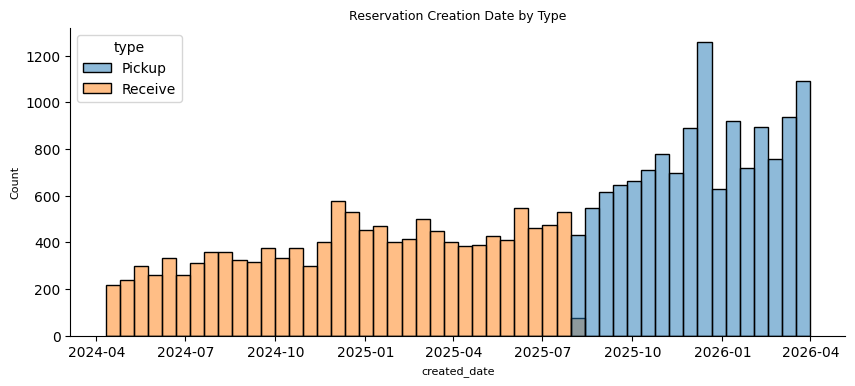

Last appearance of 'Receive': 2025-07-31 00:00:00
First appearance of 'Pickup': 2025-08-01 00:00:00


In [ ]:
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
plt.figure(figsize=(10,4))
sns.histplot(data=df, x='created_date', hue='type', bins=50, alpha=0.5)
plt.title('Reservation Creation Date by Type')
plt.show()

# Aggregate daily counts per type
daily_counts = df.groupby([df['created_date'].dt.date, 'type']).size().unstack(fill_value=0)
daily_counts.index = pd.to_datetime(daily_counts.index)

# Find the date when Receive last appears and Pickup first appears
last_receive = daily_counts[daily_counts['Receive'] > 0].index.max() if 'Receive' in daily_counts.columns else None
first_pickup = daily_counts[daily_counts['Pickup'] > 0].index.min() if 'Pickup' in daily_counts.columns else None

if last_receive:
    print(f"Last appearance of 'Receive': {last_receive}")
if first_pickup:
    print(f"First appearance of 'Pickup': {first_pickup}")

In [ ]:
# Filter by delivery and pickup status
not_picked_or_not_delivered = len(df.loc[(df['delivered'] == False) | (df["withdrawn"] == False)])
print(f"Parcels not picked up or not delivered: {not_picked_or_not_delivered} ({not_picked_or_not_delivered/len(df)*100:.4f}%)")

# Remove parcels which have missing pickup time
df = df.loc[(df['delivered'] == True) & (df["withdrawn"] == True)]

Parcels not picked up or not delivered: 7 (0.0268%)


Columns with missing values:
                                       missing_count  missing_pct
collect_duration                               26158   100.000000
send_duration                                  26158   100.000000
bin                                             1377     5.264164
bbl                                             1377     5.264164
council_district                                1361     5.202997
community_board                                 1361     5.202997
census_tract_2020                               1361     5.202997
neighborhood_tabulation_area_nta_2020           1361     5.202997
df_loc_index                                     603     2.305222
receive_date                                       1     0.003823
delivery_duration                                  1     0.003823


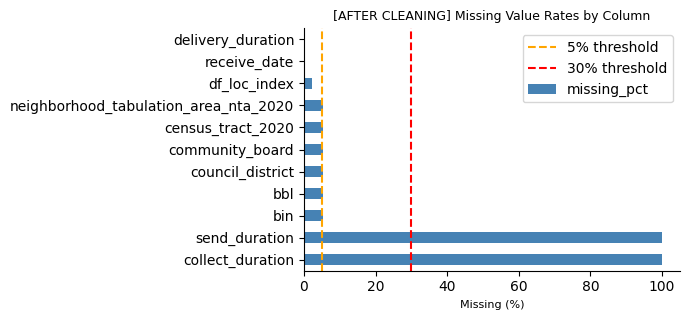

In [ ]:
# Missing values after cleaning
missing = (
    df.isnull()
    .sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda x: x['missing_count'] / len(df) * 100)
    .sort_values('missing_pct', ascending=False)
)
missing = missing[missing['missing_count'] > 0]

print('Columns with missing values:')
print(missing.to_string())

if not missing.empty:
    fig, ax = plt.subplots(figsize=(7, max(3, len(missing)*0.3)))
    missing['missing_pct'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title('[AFTER CLEANING] Missing Value Rates by Column')
    ax.axvline(5, color='orange', linestyle='--', label='5% threshold')
    ax.axvline(30, color='red', linestyle='--', label='30% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('✓ No missing values found.')

---
### 1.4. Creating / Modify Colunmns

Feature Engineering

In [ ]:
# Convert duration columns to hours
def duration_to_hours(duration_str):
    if pd.isnull(duration_str):
        return np.nan
    try:
        parts = str(duration_str).strip().split('.')

        if len(parts) != 4:
            return np.nan  # unexpected format

        days, hours, minutes, seconds = map(int, parts)
        return round((days * 24 + hours + minutes / 60 + seconds / 3600), 2)

    except Exception as e:
        print(f"Error parsing: {duration_str}")
        return np.nan

duration_cols = ["pickup_duration", "delivery_duration"]

for col in duration_cols:
    if col in df.columns:
        df[col] = df[col].apply(duration_to_hours)

# Apply the datetime to date columns
date_cols = ["expire_date", "delivery_date", "withdraw_date", "created_date"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if "receive_date" in df.columns:
    df["receive_date"] = pd.to_datetime(
        df["receive_date"],
        format='%m/%d/%Y %I:%M:%S %p',
        errors='coerce')

# Add calculated columns
df["expiry_duration_days"] = (df["expire_date"] - df["delivery_date"]).dt.days
df['hours_to_delivery'] = (df['delivery_date'] - df['created_date']).dt.total_seconds() / 3600

# Add time features
def add_time_features(df, col, prefix):
    df[f'{prefix}_hour'] = df[col].dt.hour
    df[f'{prefix}_day'] = df[col].dt.day
    df[f'{prefix}_week'] = df[col].dt.isocalendar().week
    df[f'{prefix}_month'] = df[col].dt.month
    df[f'{prefix}_day_of_week'] = df[col].dt.day_name()

add_time_features(df, 'withdraw_date', 'withdraw')
add_time_features(df, 'delivery_date', 'delivery')
add_time_features(df, 'receive_date', 'receive')

# Add holiday features
us_holidays = holidays.UnitedStates(years=range(2024, 2027))
df["withdrawn_on_holiday"] = df["withdraw_date"].dt.normalize().isin(us_holidays).astype(int)
df["delivered_on_holiday"] = df["delivery_date"].dt.normalize().isin(us_holidays).astype(int)

/tmp/ipykernel_2398/1432655310.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_2398/1432655310.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_2398/1432655310.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_2398/1432655310.py:55: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, th

In [ ]:
# Remove not needed columns
cols_to_drop = ['type', 'location_type', 'send_duration', 'collect_duration',
                'withdrawn', 'delivered', 'status', 'received']
df = df.drop(columns=cols_to_drop)

# Add index
df = df.reset_index().rename(columns={'index': 'id'})

In [ ]:
# Distance to borough center
borough_centers = {
    'Manhattan': (40.7831, -73.9712),     # Times Square area
    'Brooklyn': (40.6782, -73.9442),      # Downtown Brooklyn
    'Queens': (40.7282, -73.7949),        # Long Island City
    'Bronx': (40.8448, -73.8648),         # The Hub
    'Staten Island': (40.5795, -74.1502)} # St. George

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

def compute_distance(row):
    borough = row['borough']
    if borough not in borough_centers:
        return np.nan
    lat1, lon1 = row['latitude'], row['longitude']
    lat2, lon2 = borough_centers[borough]
    return haversine(lat1, lon1, lat2, lon2)

df['distance_to_borough_center_km'] = df.apply(compute_distance, axis=1)

In [ ]:
print("\n" + "="*60)
print(f"CLEANING COMPLETE: {df.shape[0]:,} rows, {df.shape[1]:,} columns")
print("="*60)
print("\nFinal column names (standardized snake_case):")
print(df.columns.tolist())


CLEANING COMPLETE: 26,158 rows, 45 columns

Final column names (standardized snake_case):
['id', 'created_date', 'delivery_date', 'receive_date', 'withdraw_date', 'expired', 'expire_date', 'locker_name', 'locker_box_door', 'pickup_duration', 'delivery_duration', 'address', 'latitude', 'longitude', 'borough', 'community_board', 'council_district', 'bin', 'bbl', 'census_tract_2020', 'neighborhood_tabulation_area_nta_2020', 'df_index', 'df_loc_index', 'locker_size', 'location', 'expiry_duration_days', 'hours_to_delivery', 'withdraw_hour', 'withdraw_day', 'withdraw_week', 'withdraw_month', 'withdraw_day_of_week', 'delivery_hour', 'delivery_day', 'delivery_week', 'delivery_month', 'delivery_day_of_week', 'receive_hour', 'receive_day', 'receive_week', 'receive_month', 'receive_day_of_week', 'withdrawn_on_holiday', 'delivered_on_holiday', 'distance_to_borough_center_km']


---
# 2. `EDA`

---
### 1. Target Variable Analysis – Package Pickup Time

> **Definition:** Pickup = how long a package sits in the locker after it is dropoffed into a locker by driver and picked-up by customer.  

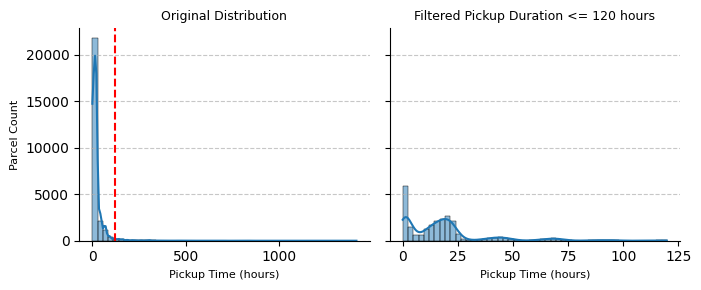


--- Outlier Analysis ---
Count of parcels picked up after 120 hours: 616
Proportion of outliers: 2.35%


In [ ]:
# Filter data for visualization (cap at 120 hours for better readability)
df_filtered_pickup = df[df['pickup_duration'] <= 120]

fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

# Original data
sns.histplot(data=df, x='pickup_duration', kde=True, bins=50, ax=axes[0])
axes[0].axvline(120, color='red', linestyle='--')
axes[0].set_title('Original Distribution')
axes[0].set_xlabel('Pickup Time (hours)')
axes[0].set_ylabel('Parcel Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Filtered data (<120 hours)
sns.histplot(data=df_filtered_pickup, x='pickup_duration', kde=True, bins=50, ax=axes[1])
axes[1].set_title('Filtered Pickup Duration <= 120 hours')
axes[1].set_xlabel('Pickup Time (hours)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Outlier analysis - parcels with dwell time > 5 days (120 hours)
five_days_threshold = 24 * 5
outl_long_dwell_time = df["id"].loc[df["pickup_duration"] > five_days_threshold].nunique()

print(f"\n--- Outlier Analysis ---")
print(f"Count of parcels picked up after {five_days_threshold} hours: {outl_long_dwell_time}")
print(f"Proportion of outliers: {(outl_long_dwell_time / len(df)) * 100:.2f}%")

In [ ]:
# Summary statistics before and after filtering
orig_desc = df['pickup_duration'].describe()
filt_desc = df_filtered_pickup['pickup_duration'].describe()

summary = pd.concat([orig_desc, filt_desc], axis=1, keys=['Original', 'Filtered (≤120h)'])
print("\nSummary Statistics Comparison:")
print(summary.round(2))


Summary Statistics Comparison:
       Original  Filtered (≤120h)
count  26158.00          25542.00
mean      24.23             18.56
std       49.82             19.64
min        0.01              0.01
25%        3.14              2.94
50%       16.15             15.81
75%       22.53             22.02
max     1413.54            119.71


In [ ]:
# Remove outliers with pickup duration longer than 5 days (120 hours)
df = df[df['pickup_duration'] <= five_days_threshold]
print(f"\n✓ Removed outliers. New dataset size: {len(df):,} rows")


✓ Removed outliers. New dataset size: 25,542 rows


/tmp/ipykernel_2398/1020732350.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis', 4)


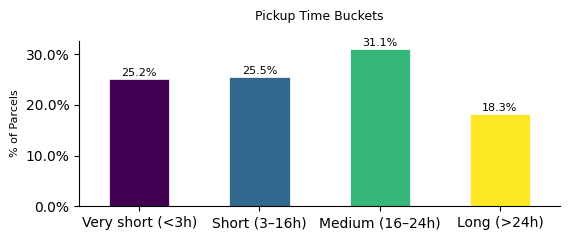

In [ ]:
# Create categorical buckets for pickup duration
bins = [0, 3, 16, 24, np.inf]
labels = ['Very short (<3h)', 'Short (3–16h)', 'Medium (16–24h)', 'Long (>24h)']

df['pickup_bucket'] = pd.cut(df['pickup_duration'], bins=bins, labels=labels)

# Calculate bucket distribution
bucket_dist = (
    df['pickup_bucket']
    .value_counts(normalize=True)
    .mul(100)
    .reindex(labels)
)

# Sample 4 evenly spaced colours from viridis — same palette as borough/location plots
viridis = cm.get_cmap('viridis', 4)
colors = [viridis(i) for i in np.linspace(0, 0.75, 4)]

fig, ax = plt.subplots(figsize=(5.8, 2.5))
bucket_dist.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Pickup Time Buckets', pad=15)
ax.set_xlabel('')
ax.set_ylabel('% of Parcels')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=0)

# Add percentage labels on bars
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=8)
plt.tight_layout()
plt.show()

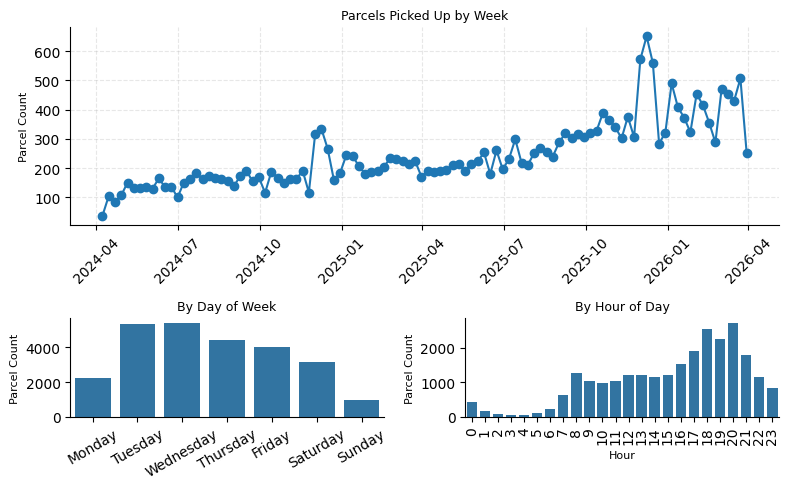

In [ ]:
# Ensure datetime format and create time features if not already present
df['withdraw_date'] = pd.to_datetime(df['withdraw_date'])

# Create time features if they don't exist
if 'withdraw_hour' not in df.columns:
    df['withdraw_hour'] = df['withdraw_date'].dt.hour
    df['withdraw_day'] = df['withdraw_date'].dt.day
    df['withdraw_week'] = df['withdraw_date'].dt.isocalendar().week
    df['withdraw_month'] = df['withdraw_date'].dt.month
    df['withdraw_day_of_week'] = df['withdraw_date'].dt.day_name()

# Create weekly aggregation for trend line
if 'withdraw_week_start' not in df.columns:
    df['withdraw_week_start'] = df['withdraw_date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_counts = df.groupby('withdraw_week_start').size().reset_index(name='parcel_count')

# Order for days of week
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Create multi-panel figure
fig = plt.figure(figsize=(8, 5))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

# Weekly trend
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(weekly_counts['withdraw_week_start'], weekly_counts['parcel_count'], marker='o', linewidth=1.5)
ax1.set_title('Parcels Picked Up by Week')
ax1.set_ylabel('Parcel Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.3)

# Hourly distribution
ax2 = fig.add_subplot(gs[1, 1])
sns.countplot(x='withdraw_hour', data=df, order=list(range(24)), ax=ax2)
ax2.set_title('By Hour of Day')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Parcel Count')
ax2.tick_params(axis='x', rotation=90)

# Day of week distribution
ax3 = fig.add_subplot(gs[1, 0])
sns.countplot(x='withdraw_day_of_week', data=df, order=order, ax=ax3)
ax3.set_title('By Day of Week')
ax3.set_xlabel('')
ax3.set_ylabel('Parcel Count')
ax3.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 2. Deliveries & Received at the warehouse

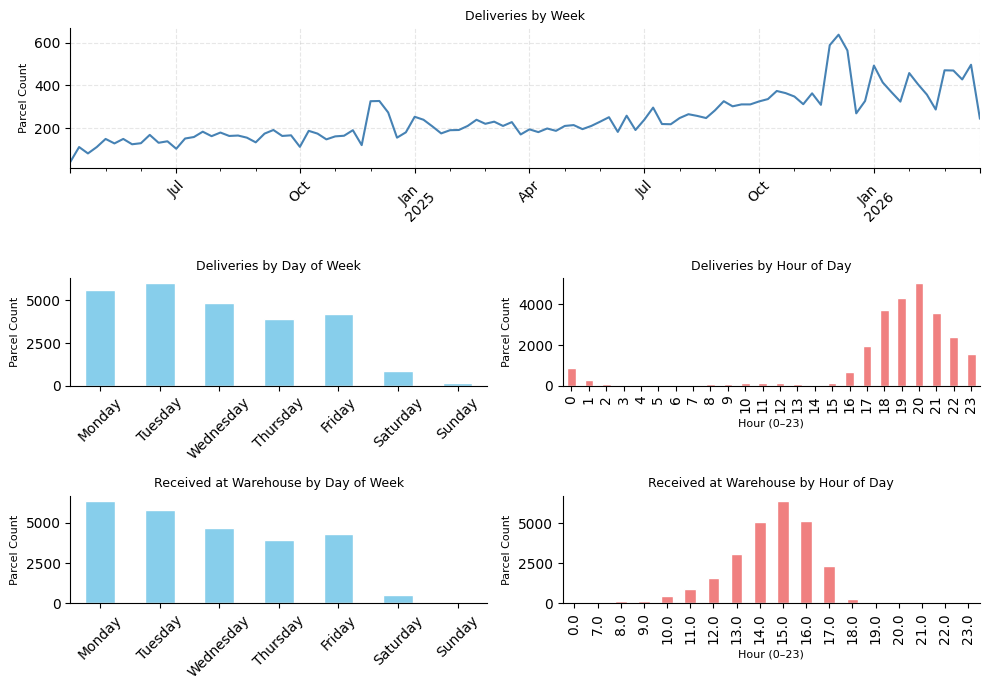

In [ ]:
# TEMPORAL PATTERNST

# Prepare delivery date features
df['delivery_date'] = pd.to_datetime(df['delivery_date'])

# Create time features if they don't exist (in case cleaning didn't create them)
if 'delivery_hour' not in df.columns:
    df['delivery_hour'] = df['delivery_date'].dt.hour
    df['delivery_day'] = df['delivery_date'].dt.day
    df['delivery_week'] = df['delivery_date'].dt.isocalendar().week
    df['delivery_month'] = df['delivery_date'].dt.month
    df['delivery_day_of_week'] = df['delivery_date'].dt.day_name()

# Create weekly aggregation
if 'delivery_week_start' not in df.columns:
    df['delivery_week_start'] = df['delivery_date'].dt.to_period('W').apply(lambda r: r.start_time)

delivery_week = df.groupby('delivery_week_start').size()
delivery_weekday = df['delivery_day_of_week'].value_counts().reindex(order)
delivery_hour = df['delivery_hour'].value_counts().sort_index()

# Warehouse receipt metrics (if receive_date exists)
if 'receive_date' in df.columns:
    # Create receive time features if they don't exist
    df['receive_date'] = pd.to_datetime(df['receive_date'])

    if 'receive_hour' not in df.columns:
        df['receive_hour'] = df['receive_date'].dt.hour
        df['receive_day'] = df['receive_date'].dt.day
        df['receive_week'] = df['receive_date'].dt.isocalendar().week
        df['receive_month'] = df['receive_date'].dt.month
        df['receive_day_of_week'] = df['receive_date'].dt.day_name()

    receive_weekday = df['receive_day_of_week'].value_counts().reindex(order)
    receive_hour = df['receive_hour'].value_counts().sort_index()
    has_receive_data = True
else:
    receive_weekday = pd.Series(dtype=int)
    receive_hour = pd.Series(dtype=int)
    has_receive_data = False
    print("Note: 'receive_date' column not found - skipping warehouse receipt visualizations")

# Create multi-panel figure
fig = plt.figure(figsize=(10, 7))
gs = fig.add_gridspec(3, 2, height_ratios=[1.3, 1, 1])

# Weekly delivery trend
ax0 = fig.add_subplot(gs[0, :])
delivery_week.plot(ax=ax0, color='steelblue', linewidth=1.5)
ax0.set_title('Deliveries by Week')
ax0.set_xlabel('')
ax0.set_ylabel('Parcel Count')
ax0.tick_params(axis='x', rotation=45)
ax0.grid(True, linestyle='--', alpha=0.3)

# Deliveries - day of week
ax1 = fig.add_subplot(gs[1, 0])
delivery_weekday.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='white')
ax1.set_title('Deliveries by Day of Week')
ax1.set_xlabel('')
ax1.set_ylabel('Parcel Count')
ax1.tick_params(axis='x', rotation=45)

# Deliveries - hour of day
ax2 = fig.add_subplot(gs[1, 1])
delivery_hour.plot(kind='bar', ax=ax2, color='lightcoral', edgecolor='white')
ax2.set_title('Deliveries by Hour of Day')
ax2.set_xlabel('Hour (0–23)')
ax2.set_ylabel('Parcel Count')

# Warehouse receipt visualizations (only if data exists)
if has_receive_data and not receive_weekday.empty:
    ax3 = fig.add_subplot(gs[2, 0])
    receive_weekday.plot(kind='bar', ax=ax3, color='skyblue', edgecolor='white')
    ax3.set_title('Received at Warehouse by Day of Week')
    ax3.set_xlabel('')
    ax3.set_ylabel('Parcel Count')
    ax3.tick_params(axis='x', rotation=45)

    ax4 = fig.add_subplot(gs[2, 1])
    receive_hour.plot(kind='bar', ax=ax4, color='lightcoral', edgecolor='white')
    ax4.set_title('Received at Warehouse by Hour of Day')
    ax4.set_xlabel('Hour (0–23)')
    ax4.set_ylabel('Parcel Count')

    # Optional: Add a subtitle for the warehouse section
    # fig.text(0.5, 0.31, 'Received at Warehouse', ha='center', fontsize=12, fontweight='bold')
else:
    # If no warehouse data, hide or adjust the bottom subplots
    # Just add empty subplots or remove them
    for idx in range(2, 4):
        fig.add_subplot(gs[2, idx-2]).set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# EDA for Delivery Duration column
# 1. Basic info
print(f"Data type: {df['delivery_duration'].dtype}")
print(f"Missing values: {df['delivery_duration'].isna().sum()}")
print(f"Missing percentage: {df['delivery_duration'].isna().mean() * 100:.2f}%")
print(f"Unique values: {df['delivery_duration'].nunique()}")

# 2. Convert to numeric hours (using your duration_to_hours function)
if df['delivery_duration'].dtype == 'object':
    df['delivery_duration_hrs'] = df['delivery_duration'].apply(duration_to_hours)
else:
    df['delivery_duration_hrs'] = df['delivery_duration']

# 3. Basic statistics (only non-missing)
delivery_valid = df['delivery_duration_hrs'].dropna()
print("\nDelivery Duration (hours) - Statistics:")
print(delivery_valid.describe())

Data type: float64
Missing values: 1
Missing percentage: 0.00%
Unique values: 3050

Delivery Duration (hours) - Statistics:
count    25541.000000
mean         8.651034
std         18.009004
min         -0.220000
25%          3.650000
50%          5.380000
75%          7.780000
max       1176.760000
Name: delivery_duration_hrs, dtype: float64


Positive delivery durations: 25540 (removed 1 negative values)


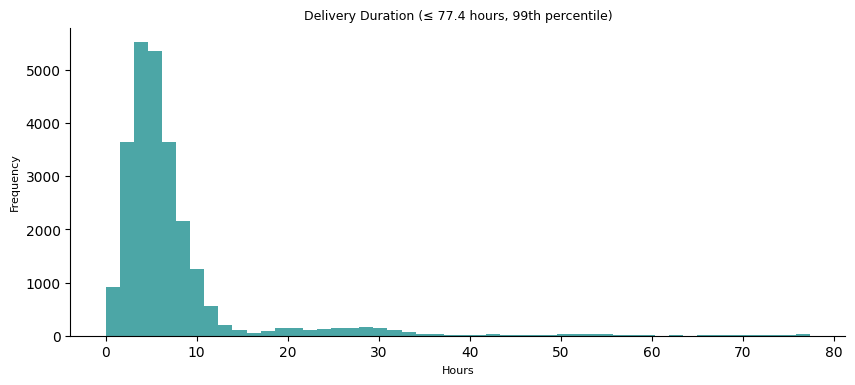

In [ ]:
# Better EDA for Delivery Duration using log scale and violin plot

# Filter out negative values (data error) for plotting
delivery_pos = df['delivery_duration_hrs'][df['delivery_duration_hrs'] > 0].dropna()

print(f"Positive delivery durations: {len(delivery_pos)} (removed {len(df['delivery_duration_hrs'].dropna()) - len(delivery_pos)} negative values)")

# 3. Boxplot focusing on the 1st to 99th percentile to ignore extreme outliers
q99 = delivery_pos.quantile(0.99)
filtered = delivery_pos[delivery_pos <= q99]
plt.figure(figsize=(10,4))
plt.hist(filtered, bins=50, color='teal', alpha=0.7)
plt.title(f'Delivery Duration (≤ {q99:.1f} hours, 99th percentile)')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

### 3. Check Expiry Time
- According to the website of Go Locker the custumer have 24-72 hours to pickup a parcel

"After receiving a text or e-mail notification confirming delivery to a locker, you’ll have 24-72 hours pick up your package(s)."
https://www.golocker.com/locker-nyc

/tmp/ipykernel_2398/2645573304.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


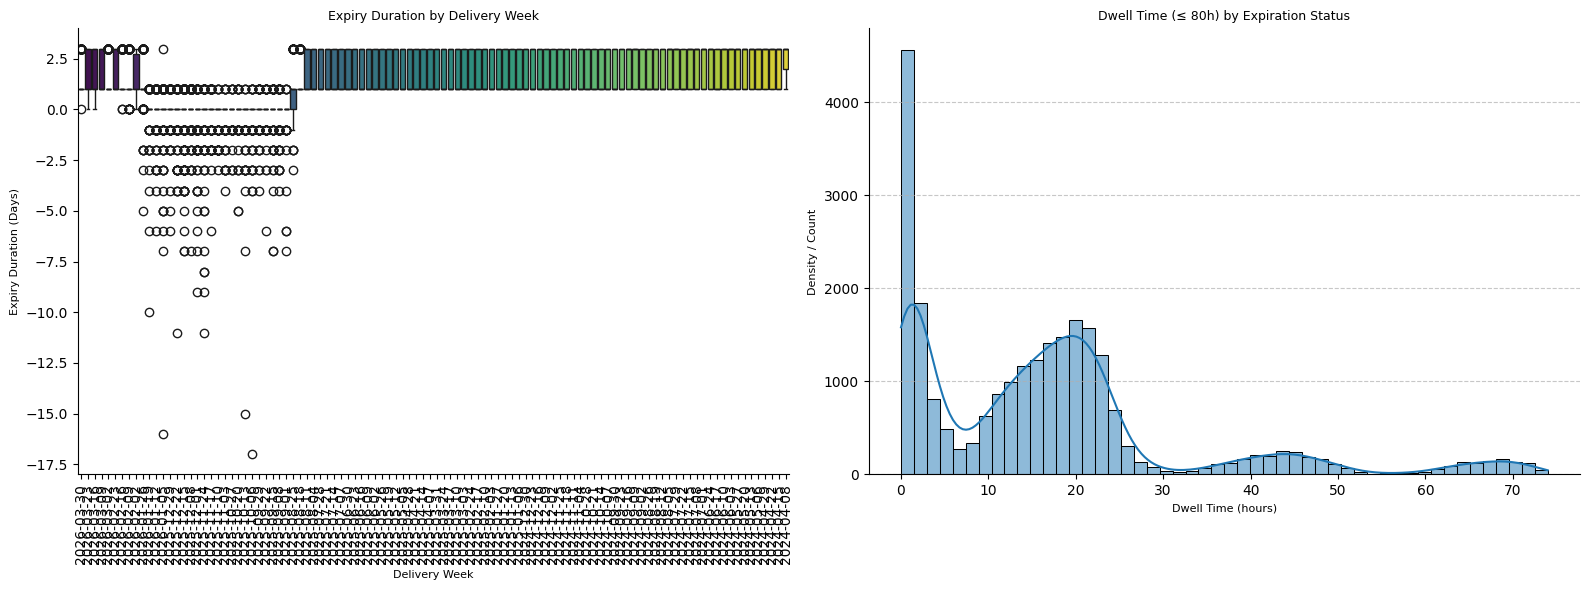

Negative Expiry Time: 746


In [ ]:
plot_df = df.dropna(subset=['expiry_duration_days', 'delivery_week_start'])
df_filtered_dwell = df[df['pickup_duration'] <= 74]

# ---- Subplots ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Boxplot ---
sns.boxplot(
    x='delivery_week_start',
    y='expiry_duration_days',
    data=plot_df,
    palette='viridis',
    ax=axes[0]
    )
axes[0].set_title('Expiry Duration by Delivery Week')
axes[0].set_xlabel('Delivery Week')
axes[0].set_ylabel('Expiry Duration (Days)')
axes[0].tick_params(axis='x', rotation=90)

# --- Right: Histogram ---
sns.histplot(
    data=df_filtered_dwell,
    x='pickup_duration',
    kde=True,
    bins=50,
    ax=axes[1]
)
axes[1].set_title('Dwell Time (≤ 80h) by Expiration Status')
axes[1].set_xlabel('Dwell Time (hours)')
axes[1].set_ylabel('Density / Count')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Negative Expiry Time:", len(df.loc[df["expiry_duration_days"] < 0]))

In [ ]:
expiry_cols_to_drop = ['expired', 'expire_date']
df = df.drop(columns=expiry_cols_to_drop)

### 4. Geographic / Location Patterns

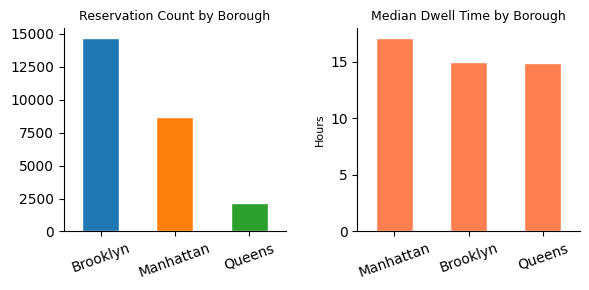


Borough Statistics:
           count  median_dwell  mean_dwell
borough                                   
Brooklyn   14692         14.96       17.81
Manhattan   8720         17.10       20.19
Queens      2130         14.92       17.11


In [ ]:
# Aggregate borough statistics
borough_stats = (
    df.groupby('borough')
    .agg(
        count=('pickup_duration', 'size'),
        median_dwell=('pickup_duration', 'median'),
        mean_dwell=('pickup_duration', 'mean')
    )
    .sort_values('count', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Borough volume
borough_stats['count'].plot(kind='bar', ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('Reservation Count by Borough')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

# Borough median dwell time
borough_stats['median_dwell'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Median Dwell Time by Borough')
axes[1].set_ylabel('Hours')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
print("\nBorough Statistics:")
print(borough_stats.round(2))

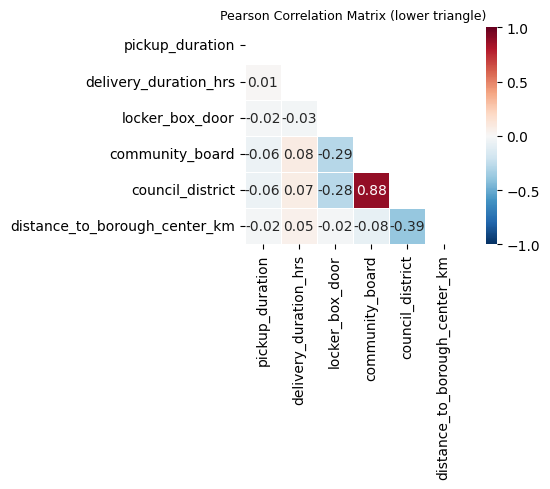

In [ ]:
# Correlation matrix
num_cols = ['pickup_duration', 'delivery_duration_hrs', 'locker_box_door',
            'community_board', 'council_district', 'distance_to_borough_center_km']

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Pearson Correlation Matrix (lower triangle)')
plt.tight_layout()
plt.show()

### Delivery Duration hours VS Pickup time


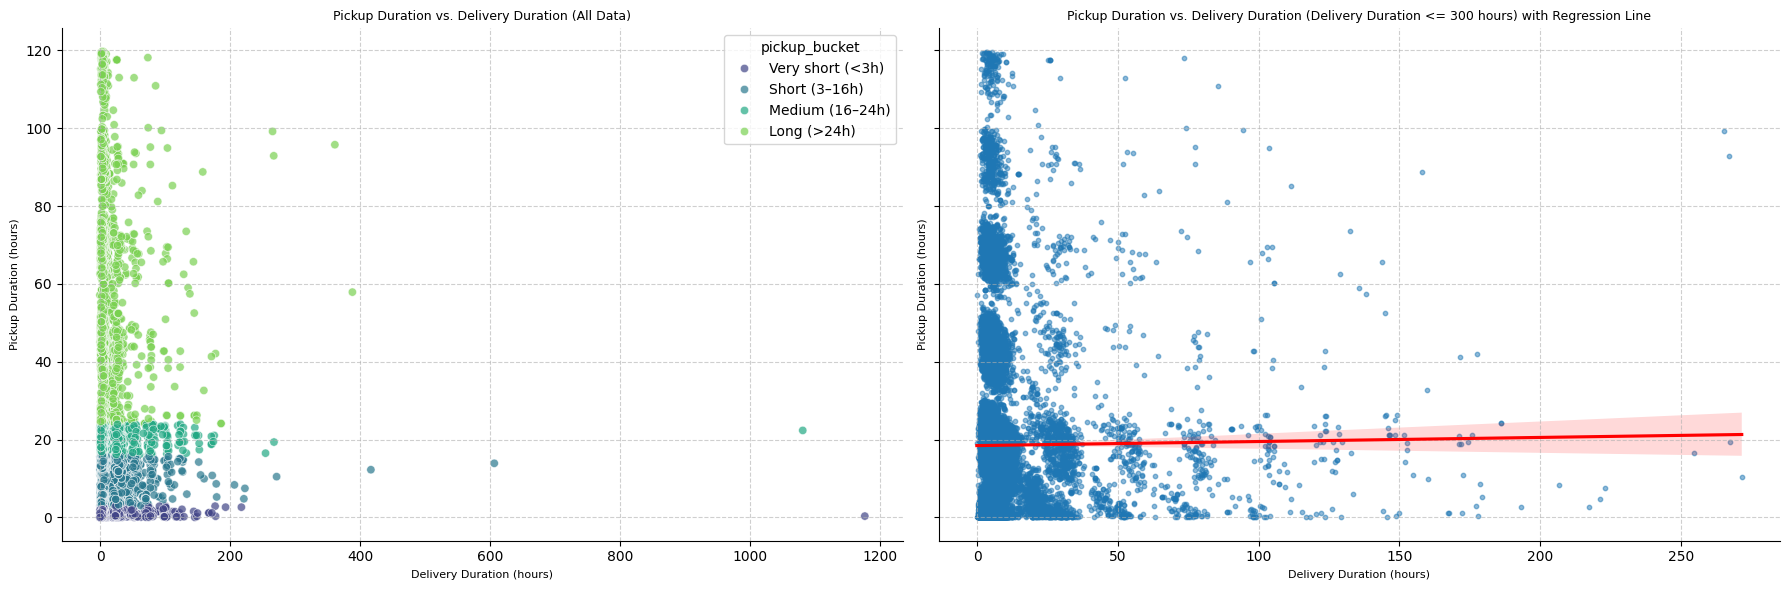

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Original scatterplot (all data)
sns.scatterplot(data=df, x='delivery_duration_hrs', y='pickup_duration', hue='pickup_bucket', palette='viridis', alpha=0.7, ax=axes[0])
axes[0].set_title('Pickup Duration vs. Delivery Duration (All Data)')
axes[0].set_xlabel('Delivery Duration (hours)')
axes[0].set_ylabel('Pickup Duration (hours)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Filtered scatterplot (delivery_duration_hrs <= 300)
df_plot_filtered = df[df['delivery_duration_hrs'] <= 300].copy()
sns.regplot(data=df_plot_filtered, x='delivery_duration_hrs', y='pickup_duration', ax=axes[1], scatter_kws={'alpha':0.5, 's':10}, line_kws={'color':'red'})
axes[1].set_title('Pickup Duration vs. Delivery Duration (Delivery Duration <= 300 hours) with Regression Line')
axes[1].set_xlabel('Delivery Duration (hours)')
axes[1].set_ylabel('Pickup Duration (hours)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Distance to Borought Center VS Pickup Duration

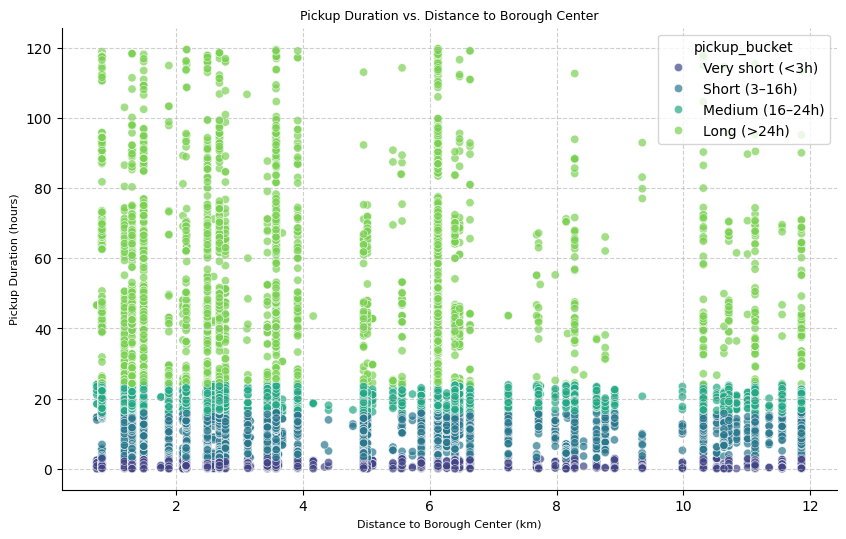

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance_to_borough_center_km', y='pickup_duration', hue='pickup_bucket', palette='viridis', alpha=0.7)
plt.title('Pickup Duration vs. Distance to Borough Center')
plt.xlabel('Distance to Borough Center (km)')
plt.ylabel('Pickup Duration (hours)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Average Pickup Time by Locker Name

Showing top 20 lockers (out of 74)


/tmp/ipykernel_2398/1012676493.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=locker_avg_pickup.index, y=locker_avg_pickup.values, palette='viridis')


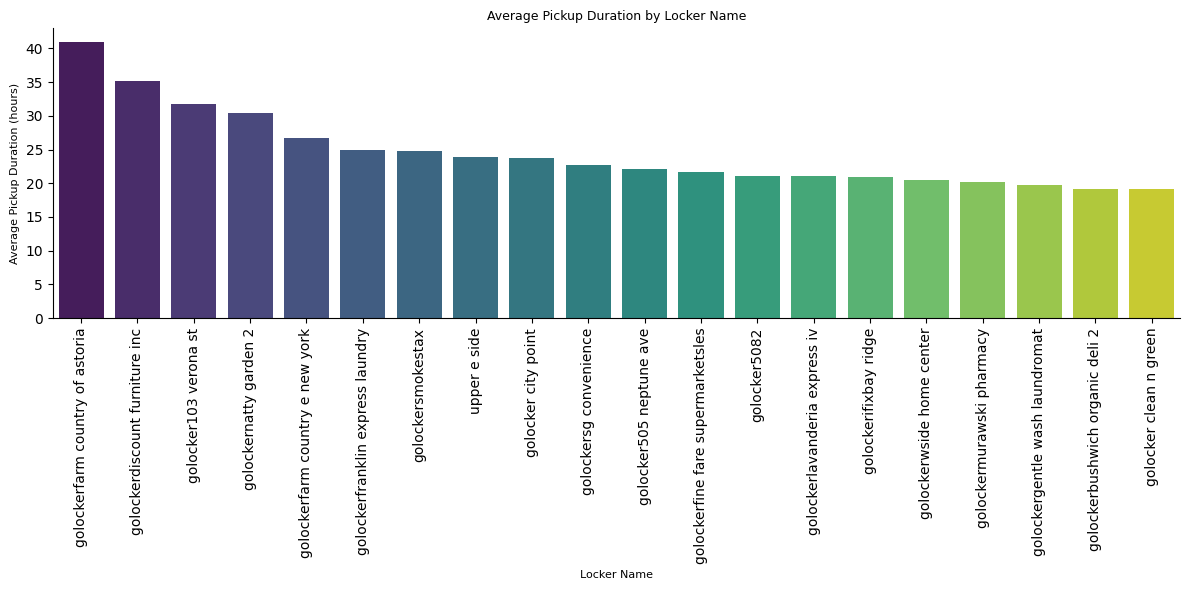

In [ ]:
# Average pickup duration by locker name
locker_avg_pickup = df.groupby('locker_name')['pickup_duration'].mean().sort_values(ascending=False)

# Limit to top 20 for readability
if len(locker_avg_pickup) > 20:
    locker_avg_pickup = locker_avg_pickup.head(20)
    print(f"Showing top 20 lockers (out of {len(df['locker_name'].unique())})")

plt.figure(figsize=(12, 6))
sns.barplot(x=locker_avg_pickup.index, y=locker_avg_pickup.values, palette='viridis')
plt.title('Average Pickup Duration by Locker Name')
plt.xlabel('Locker Name')
plt.ylabel('Average Pickup Duration (hours)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Check Distribution of Parcel count and Avg Pickup Time by week

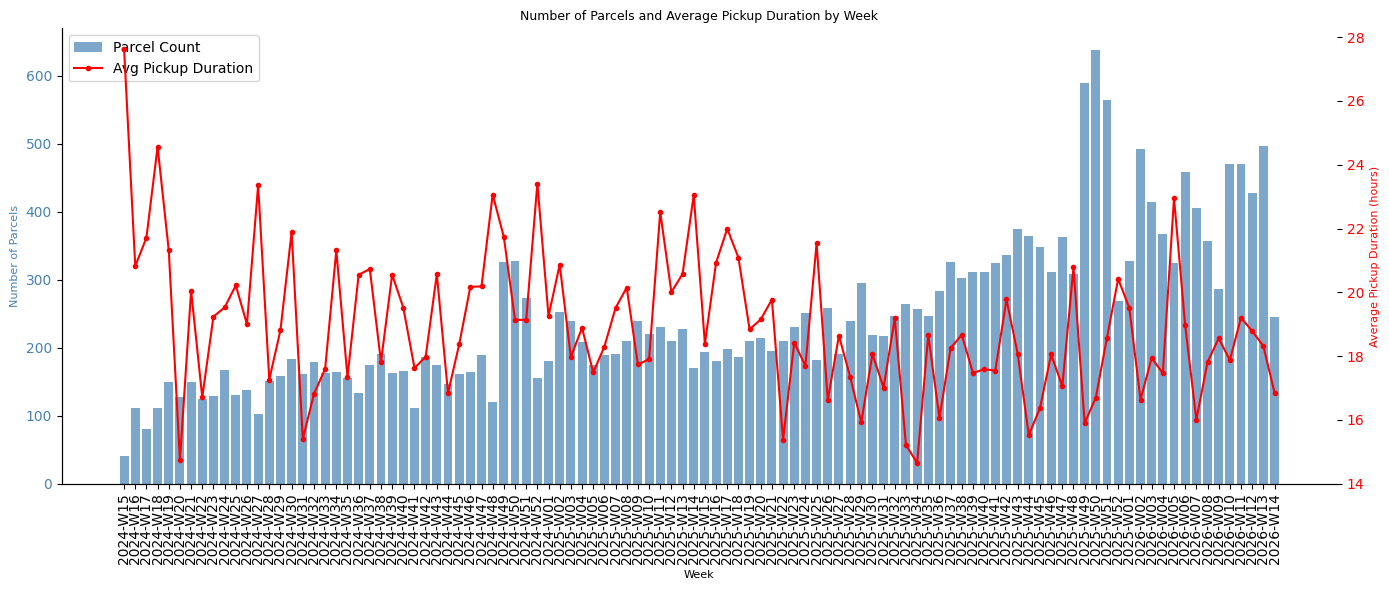

In [ ]:
if 'delivery_week_start' in df.columns:
    # Create year_week column if it doesn't exist
    if 'year_week' not in df.columns:
        df['year_week'] = df['delivery_week_start'].dt.strftime('%Y-W%V')

# ── Aggregate by year-week ────────────────────────────────────────────────────
weekly = (
    df.groupby('delivery_week_start')
    .agg(
        parcel_count=('id', 'count'),
        avg_pickup=('pickup_duration', 'mean'))
    .reset_index()
    .sort_values('delivery_week_start'))

x = range(len(weekly))

fig, ax1 = plt.subplots(figsize=(14, 6))

# ── Bar chart ─────────────────────────────────────────────────────────────────
# Bar chart for parcel count
ax1.bar(x, weekly['parcel_count'], color='steelblue', alpha=0.7, label='Parcel Count')
ax1.set_ylabel('Number of Parcels', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(list(x))
ax1.set_xticklabels(weekly['delivery_week_start'].dt.strftime('%Y-W%V'), rotation=90)
ax1.set_xlabel('Week')

# ── Line chart ────────────────────────────────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(x, weekly['avg_pickup'], color='red', marker='o', linewidth=1.5,
         markersize=3, label='Avg Pickup Duration')
ax2.set_ylabel('Average Pickup Duration (hours)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# ── Legend & layout ───────────────────────────────────────────────────────────
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.tick_params(axis='x', rotation=90)


ax1.set_title('Number of Parcels and Average Pickup Duration by Week')
fig.tight_layout()
plt.show()

#### Check how long does it take to deliver the parcel

/tmp/ipykernel_2398/1790623366.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  parcel_counts = df_filtered_hours.groupby('hours_to_delivery_bucket')['id'].count().reset_index()


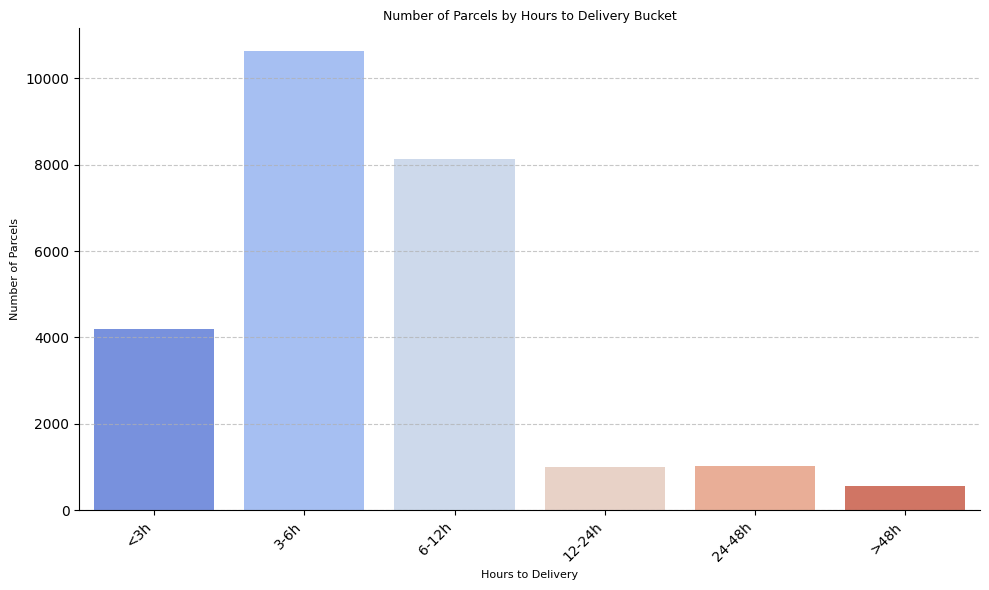

In [ ]:
df_filtered_hours = df[df['hours_to_delivery'] > 0].copy()

# Define bins for 'hours_to_delivery'
hours_bins = [0, 3, 6, 12, 24, 48, df_filtered_hours['hours_to_delivery'].max() + 1]
hours_labels = ['<3h', '3-6h', '6-12h', '12-24h', '24-48h', '>48h']

df_filtered_hours['hours_to_delivery_bucket'] = pd.cut(
    df_filtered_hours['hours_to_delivery'],
    bins=hours_bins,
    labels=hours_labels,
    right=False,
    include_lowest=True
)

# Calculate the number of parcels for each hours_to_delivery bucket
parcel_counts = df_filtered_hours.groupby('hours_to_delivery_bucket')['id'].count().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='hours_to_delivery_bucket', y='id', data=parcel_counts, palette='coolwarm', hue='hours_to_delivery_bucket', legend=False)
plt.title('Number of Parcels by Hours to Delivery Bucket')
plt.xlabel('Hours to Delivery')
plt.ylabel('Number of Parcels')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Indoor / Outdoor Location & Pickup Time

Average Pickup Duration by Location:
location
Indoor     21.237462
Outdoor    15.974955
Name: pickup_duration, dtype: float64


/tmp/ipykernel_2398/239505489.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_pickup_by_location.index, y=avg_pickup_by_location.values, palette='viridis', legend=False)


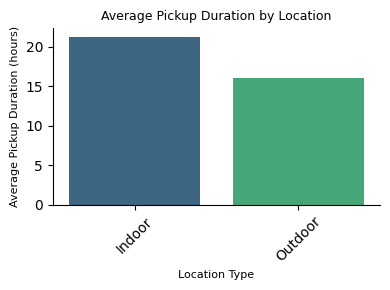

In [ ]:
avg_pickup_by_location = df.groupby('location')['pickup_duration'].mean().sort_values(ascending=False)
print("Average Pickup Duration by Location:")
print(avg_pickup_by_location)

plt.figure(figsize=(4, 3))
sns.barplot(x=avg_pickup_by_location.index, y=avg_pickup_by_location.values, palette='viridis', legend=False)
plt.title('Average Pickup Duration by Location')
plt.xlabel('Location Type')
plt.ylabel('Average Pickup Duration (hours)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2398/4181178955.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2398/4181178955.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


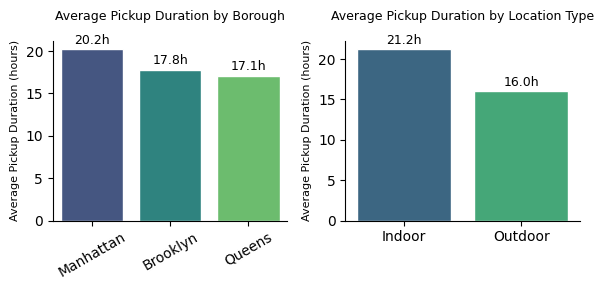

Average Pickup Duration by Borough:
  borough  pickup_duration
Manhattan             20.2
 Brooklyn             17.8
   Queens             17.1

Average Pickup Duration by Location:
location  pickup_duration
  Indoor             21.2
 Outdoor             16.0


In [ ]:
# ── Aggregate ─────────────────────────────────────────────────────────────────
borough_stats = (
    df.groupby('borough')['pickup_duration']
    .mean()
    .round(1)
    .sort_values(ascending=False)
    .reset_index()
)

location_stats = (
    df.groupby('location')['pickup_duration']
    .mean()
    .round(1)
    .sort_values(ascending=False)
    .reset_index()
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Borough
sns.barplot(
    data=borough_stats, x='borough', y='pickup_duration',
    palette='viridis', ax=axes[0], edgecolor='white'
)
axes[0].set_title('Average Pickup Duration by Borough', pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('Average Pickup Duration (hours)')
axes[0].tick_params(axis='x', rotation=30)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}h',
        ha='center', va='bottom', fontsize=9
    )

# Location
sns.barplot(
    data=location_stats, x='location', y='pickup_duration',
    palette='viridis', ax=axes[1], edgecolor='white'
)
axes[1].set_title('Average Pickup Duration by Location Type', pad=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('Average Pickup Duration (hours)')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}h',
        ha='center', va='bottom', fontsize=9
    )

# plt.suptitle('Average Pickup Duration by Borough and Location Type', fontsize=13)
plt.tight_layout()
plt.show()

# ── Print tables ──────────────────────────────────────────────────────────────
print("Average Pickup Duration by Borough:")
print(borough_stats.round(2).to_string(index=False))
print("\nAverage Pickup Duration by Location:")
print(location_stats.round(2).to_string(index=False))

### Location variables check

In [ ]:
df.columns

Index(['id', 'created_date', 'delivery_date', 'receive_date', 'withdraw_date',
       'locker_name', 'locker_box_door', 'pickup_duration',
       'delivery_duration', 'address', 'latitude', 'longitude', 'borough',
       'community_board', 'council_district', 'bin', 'bbl',
       'census_tract_2020', 'neighborhood_tabulation_area_nta_2020',
       'df_index', 'df_loc_index', 'locker_size', 'location',
       'expiry_duration_days', 'hours_to_delivery', 'withdraw_hour',
       'withdraw_day', 'withdraw_week', 'withdraw_month',
       'withdraw_day_of_week', 'delivery_hour', 'delivery_day',
       'delivery_week', 'delivery_month', 'delivery_day_of_week',
       'receive_hour', 'receive_day', 'receive_week', 'receive_month',
       'receive_day_of_week', 'withdrawn_on_holiday', 'delivered_on_holiday',
       'distance_to_borough_center_km', 'pickup_bucket', 'withdraw_week_start',
       'delivery_week_start', 'delivery_duration_hrs', 'year_week'],
      dtype='object')

In [ ]:
location_cols = [
    'latitude', 'longitude', 'borough', 'community_board',
    'council_district', 'bin', 'bbl', 'census_tract_2020',
    'neighborhood_tabulation_area_nta_2020', 'location',
    'distance_to_borough_center_km']

# Check missing values
missing_count = df[location_cols].isnull().sum()
missing_pct = (missing_count / len(df)) * 100

missing = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
}).sort_values("missing_pct", ascending=False)

print(missing)

                                       missing_count  missing_pct
bbl                                             1352         5.29
bin                                             1352         5.29
council_district                                1336         5.23
census_tract_2020                               1336         5.23
neighborhood_tabulation_area_nta_2020           1336         5.23
community_board                                 1336         5.23
latitude                                           0         0.00
borough                                            0         0.00
longitude                                          0         0.00
location                                           0         0.00
distance_to_borough_center_km                      0         0.00


In [ ]:
# Check unique value
remaining_loc = ["latitude", "longitude", "borough", "distance_to_borough_center_km"]
print(df[remaining_loc].nunique())


latitude                         135
longitude                        132
borough                            3
distance_to_borough_center_km    137
dtype: int64


In [ ]:
# Check if latitude, longitude and distance_to_borough_center_km show the same thing?
numerical_col= ["latitude", "longitude", "distance_to_borough_center_km"]

corr = df[numerical_col + ['pickup_duration']].corr()[['pickup_duration']].drop('pickup_duration')
print("Correlation with Pickup Duration:")
print(corr.round(3))


Correlation with Pickup Duration:
                               pickup_duration
latitude                                 0.018
longitude                               -0.043
distance_to_borough_center_km           -0.016


In [ ]:
# Borough median
print("\nMedian Pickup Duration by Borough:")
print(df.groupby("borough")['pickup_duration'].median().round(2))


Median Pickup Duration by Borough:
borough
Brooklyn     14.96
Manhattan    17.10
Queens       14.92
Name: pickup_duration, dtype: float64


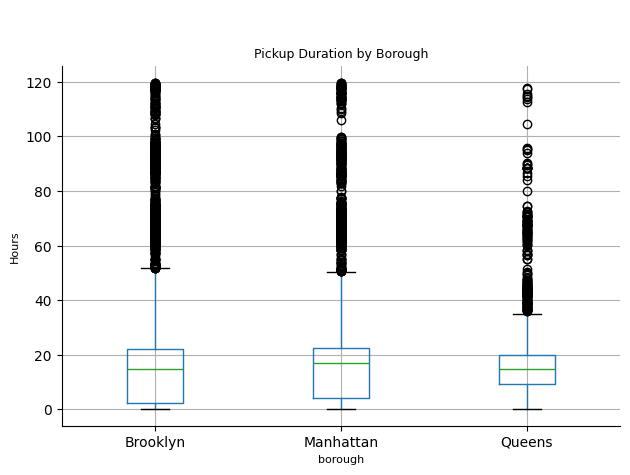

In [ ]:
# Boxplot for Borough
df.boxplot(column='pickup_duration', by="borough")
plt.title("Pickup Duration by Borough")
plt.suptitle(" ")
plt.ylabel("Hours")
plt.tight_layout()
plt.show()

# CLEANED DF

In [ ]:
df.head(5)

,id,created_date,delivery_date,receive_date,withdraw_date,locker_name,locker_box_door,pickup_duration,delivery_duration,address,latitude,longitude,borough,community_board,council_district,bin,bbl,census_tract_2020,neighborhood_tabulation_area_nta_2020,df_index,df_loc_index,locker_size,location,expiry_duration_days,hours_to_delivery,withdraw_hour,withdraw_day,withdraw_week,withdraw_month,withdraw_day_of_week,delivery_hour,delivery_day,delivery_week,delivery_month,delivery_day_of_week,receive_hour,receive_day,receive_week,receive_month,receive_day_of_week,withdrawn_on_holiday,delivered_on_holiday,distance_to_borough_center_km,pickup_bucket,withdraw_week_start,delivery_week_start,delivery_duration_hrs,year_week
0,2,2026-03-31 17:17:00,2026-03-31 22:45:00,2026-03-31 17:17:00,2026-04-01 17:14:00,golockerwside home center,26.0,18.49,5.46,778 9th ave new york ny 10019,40.764545,-73.987907,Manhattan,104.0,3.0,1078889.0,1.010420e+09,133.0,MN0402,2,1.0,S,Outdoor,1,5.466667,17,1,14,4,Wednesday,22,31,14,3,Tuesday,17.0,31.0,14,3.0,Tuesday,0,0,2.497199,Medium (16–24h),2026-03-30,2026-03-30,5.46,2026-W14
1,3,2026-03-31 17:05:00,2026-04-01 21:22:00,2026-03-31 17:05:00,2026-04-02 17:10:00,golockergentle wash laundromat,34.0,19.81,28.28,97 ave a new york ny 10009,40.725700,-73.983948,Manhattan,103.0,2.0,1005795.0,1.004340e+09,32.0,MN0303,3,56.0,S,Indoor,1,28.283333,17,2,14,4,Thursday,21,1,14,4,Wednesday,17.0,31.0,14,3.0,Tuesday,0,0,6.472239,Medium (16–24h),2026-03-30,2026-03-30,28.28,2026-W14
2,4,2026-03-31 17:04:00,2026-03-31 23:38:00,2026-03-31 17:04:00,2026-04-01 23:57:00,golocker astoria,8.0,24.32,6.57,2138 31st st queens ny 11105,40.777679,-73.909767,Queens,401.0,22.0,4017709.0,4.008460e+09,113.0,QN0101,4,72.0,L,Indoor,1,6.566667,23,1,14,4,Wednesday,23,31,14,3,Tuesday,17.0,31.0,14,3.0,Tuesday,0,0,11.130555,Long (>24h),2026-03-30,2026-03-30,6.57,2026-W14
3,5,2026-03-31 17:03:00,2026-03-31 22:08:00,2026-03-31 17:03:00,2026-04-02 11:14:00,golockerideal,14.0,37.10,5.09,2036 bedford ave brooklyn ny 11226,40.654991,-73.956468,Brooklyn,314.0,40.0,3116207.0,3.050640e+09,79602.0,BK1401,5,78.0,M,Outdoor,1,5.083333,11,2,14,4,Thursday,22,31,14,3,Tuesday,17.0,31.0,14,3.0,Tuesday,0,0,2.780412,Long (>24h),2026-03-30,2026-03-30,5.09,2026-W14
4,6,2026-03-31 17:02:00,2026-03-31 18:34:00,2026-03-31 17:02:00,2026-04-01 09:22:00,golocker taaffe pl,47.0,14.81,1.53,241 taaffe pl brooklyn ny 11205,40.690681,-73.959389,Brooklyn,303.0,33.0,3055136.0,3.019250e+09,235.0,BK0301,6,24.0,S,Outdoor,3,1.533333,9,1,14,4,Wednesday,18,31,14,3,Tuesday,17.0,31.0,14,3.0,Tuesday,0,0,1.888502,Short (3–16h),2026-03-30,2026-03-30,1.53,2026-W14


# Feature Engineering & Model Preprocessing
- select the features for modeling (based on EDA + RF Feature importance)
- scaling
- encoding
- train/test split

### Define target and select features

In [ ]:
#"Locker Name" frequency encoding
locker_counts =df['locker_name'].value_counts()
df['locker_freq'] = df['locker_name'].map(locker_counts)

# Drop original
df = df.drop(columns=['locker_name'])

In [ ]:
# Define target variable
target = 'pickup_bucket'

# Columns that would cause leakage (derived from Withdraw Date or directly give target away)
leakage_cols = [
    'withdraw_date', 'withdraw_hour', 'withdraw_day', 'withdraw_week',
    'withdraw_month', 'withdraw_day_of_week', 'withdrawn_on_holiday',
    'pickup_duration'
]

# Additional columns that are redundant or not useful for prediction
extra_drop = [
    'created_date', 'delivery_duration', 'delivery_duration_hrs',
    'receive_date', 'delivery_date',                                                       # Raw datetime - we have engineered features from them (hour, day, month...)
    'expire_date', 'expired',
    'address', 'id',                                                                       # Many unique values - overfitting
    'latitude', 'longitude',                                                               # We engineered distance_to_borough_center_km + we have borough, so these are not needed
    'bin', 'bbl', 'census_tract_2020', 'neighborhood_tabulation_area_nta_2020',            # Very granular geographical variables
    'locker_size', 'community_board', 'council_district',                                  # Too many missing values
    'locker_box_door', 'delivered_on_holiday', 'receive_month', 'delivery_month',          # Unimportant
    'receive_hour', 'receive_day_of_week', 'expiry_duration_days', 'df_loc_index', 'df_index', # Unimportant
    'receive_week', 'receive_day',                                                         # Highly correlated with delivery day / delivery week
    'withdraw_week_start', 'delivery_week_start', 'delivery_week'                          # Temporary visualisation helpers
    ]

In [ ]:
# Check if year_week exists and is string format
if 'year_week' in df.columns:
    if df['year_week'].dtype == 'object':
        # Extract week number from "2024-W03" format -> 3
        df['year_week'] = df['year_week'].str.extract(r'W(\d+)').astype(int)
        print("✓ Converted year_week from string to numeric week number")

✓ Converted year_week from string to numeric week number


In [ ]:
# Identify all columns in df
all_cols = set(df.columns)

# Features that should remain (all except target, leakage, and extra_drop)
drop_cols = set(leakage_cols + extra_drop + [target])
feature_cols = [col for col in all_cols if col not in drop_cols]

In [ ]:
print(f"Total features before cleaning: {len(feature_cols)}")
print("Feature columns:\n", feature_cols)

X = df[feature_cols].copy()
y = df[target].copy()

Total features before cleaning: 9
Feature columns:
 ['location', 'delivery_day', 'locker_freq', 'delivery_day_of_week', 'delivery_hour', 'borough', 'distance_to_borough_center_km', 'year_week', 'hours_to_delivery']


In [ ]:
print("Missing values per feature:\n")
print(X.isnull().sum())

Missing values per feature:

location                         0
delivery_day                     0
locker_freq                      0
delivery_day_of_week             0
delivery_hour                    0
borough                          0
distance_to_borough_center_km    0
year_week                        0
hours_to_delivery                0
dtype: int64


### OneHotEncoder

In [ ]:
X.head()

,location,delivery_day,locker_freq,delivery_day_of_week,delivery_hour,borough,distance_to_borough_center_km,year_week,hours_to_delivery
0,Outdoor,31,1429,Tuesday,22,Manhattan,2.497199,14,5.466667
1,Indoor,1,333,Wednesday,21,Manhattan,6.472239,14,28.283333
2,Indoor,31,475,Tuesday,23,Queens,11.130555,14,6.566667
3,Outdoor,31,3431,Tuesday,22,Brooklyn,2.780412,14,5.083333
4,Outdoor,31,1324,Tuesday,18,Brooklyn,1.888502,14,1.533333


In [ ]:
# Categotical & numerical features
cat_features = ["delivery_day_of_week", "borough", "location"]
num_features = [col for col in X.columns if col not in cat_features]

print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"Numerical features ({len(num_features)}): {num_features}")

Categorical features (3): ['delivery_day_of_week', 'borough', 'location']
Numerical features (6): ['delivery_day', 'locker_freq', 'delivery_hour', 'distance_to_borough_center_km', 'year_week', 'hours_to_delivery']


In [ ]:
# Preprocessor: one-hot encodes the categorical values. There is no need for scaling
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)])

#for logistic regression and neural network we need to scale numeric variables
preprocessor_scaled  = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)])

### Train / Test Split

In [ ]:
# Train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train.head(5)

,location,delivery_day,locker_freq,delivery_day_of_week,delivery_hour,borough,distance_to_borough_center_km,year_week,hours_to_delivery
25070,Indoor,10,1614,Monday,16,Brooklyn,2.686095,24,1.366667
18750,Indoor,4,5313,Tuesday,19,Manhattan,6.131295,6,5.666667
7046,Outdoor,8,3431,Monday,18,Brooklyn,1.491990,50,1.533333
13656,Outdoor,17,1384,Thursday,21,Manhattan,6.399116,29,6.166667
10225,Indoor,10,1328,Friday,18,Brooklyn,3.578382,41,1.500000


# MODELLING

## Logistic Regression

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Helper to build a fresh pipeline ─────────────────────────────────────────
def make_lr_pipeline(C=1.0, penalty='l2'):
    return Pipeline([
        ('preprocessor', ColumnTransformer([
            ('num', StandardScaler(), num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
        ])),
        ('model', LogisticRegression(
            penalty=penalty,
            solver='lbfgs',
            C=C,
            class_weight='balanced',
            multi_class='multinomial',
            max_iter=1000,
            random_state=42
        ))
    ])

# ── 1. No regularisation ─────────────────────────────────────────────────────
t0 = time.time()

pipe_noreg = make_lr_pipeline(C=1e6, penalty=None)

pipe_noreg.fit(X_train, y_train)

y_pred_noreg  = pipe_noreg.predict(X_test)
y_prob_noreg  = pipe_noreg.predict_proba(X_test)

rocauc_noreg = roc_auc_score(
    y_test,
    y_prob_noreg,
    multi_class='ovr',
    average='macro'
)

time_noreg = (time.time() - t0) / 60

# ── 2. L2 default C=1.0 ──────────────────────────────────────────────────────
t0 = time.time()

pipe_l2 = make_lr_pipeline(C=1.0, penalty='l2')

pipe_l2.fit(X_train, y_train)

y_pred_l2 = pipe_l2.predict(X_test)
y_prob_l2 = pipe_l2.predict_proba(X_test)

rocauc_l2 = roc_auc_score(
    y_test,
    y_prob_l2,
    multi_class='ovr',
    average='macro'
)

time_l2 = (time.time() - t0) / 60

# ── 3. L2 + tuning ───────────────────────────────────────────────────────────
t0 = time.time()

param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_search = GridSearchCV(
    estimator=make_lr_pipeline(C=1.0, penalty='l2'),
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_C = grid_search.best_params_['model__C']

pipe_tuned = grid_search.best_estimator_

y_pred_tuned = pipe_tuned.predict(X_test)
y_prob_tuned = pipe_tuned.predict_proba(X_test)

rocauc_tuned = roc_auc_score(
    y_test,
    y_prob_tuned,
    multi_class='ovr',
    average='macro'
)

time_tuned = (time.time() - t0) / 60

# ── Print results ────────────────────────────────────────────────────────────
header = lambda title: print(f"\n{'='*55}\n{title}\n{'='*55}")

header(f"1. No Regularisation (C=1e6)  [{time_noreg:.2f} min]")

print(classification_report(y_test, y_pred_noreg, digits=3))

print(f"Macro F1     : {f1_score(y_test, y_pred_noreg, average='macro'):.4f}")
print(f"Macro ROC-AUC: {rocauc_noreg:.4f}")

header(f"2. L2 Regularisation (C=1.0)  [{time_l2:.2f} min]")

print(classification_report(y_test, y_pred_l2, digits=3))

print(f"Macro F1     : {f1_score(y_test, y_pred_l2, average='macro'):.4f}")
print(f"Macro ROC-AUC: {rocauc_l2:.4f}")

header(f"3. L2 + Tuned (best C={best_C})  [{time_tuned:.2f} min]")

print(classification_report(y_test, y_pred_tuned, digits=3))

print(f"Macro F1     : {f1_score(y_test, y_pred_tuned, average='macro'):.4f}")
print(f"Macro ROC-AUC: {rocauc_tuned:.4f}")

# ── CV scores per C ──────────────────────────────────────────────────────────
print(f"\n── GridSearchCV results ──")

print(f"{'C':>10}  {'Mean CV Macro F1':>18}")
print(f"{'─'*10}  {'─'*18}")

for mean, C in sorted(
    zip(
        grid_search.cv_results_['mean_test_score'],
        param_grid['model__C']
    )
):
    marker = ' ← best' if C == best_C else ''
    print(f"{C:>10.3f}  {mean:>18.4f}{marker}")

# ── Summary table ────────────────────────────────────────────────────────────
print(f"\n── Summary ──")

print(f"{'Model':<40} {'Macro F1':>10} {'ROC-AUC':>10} {'Time (min)':>12}")

print(f"{'─'*40}  {'─'*10}  {'─'*10}  {'─'*12}")

for name, y_pred, rocauc, t in [
    ('No regularisation (C=1e6)', y_pred_noreg, rocauc_noreg, time_noreg),
    ('L2 regularisation (C=1.0)', y_pred_l2, rocauc_l2, time_l2),
    (f'L2 tuned (C={best_C})', y_pred_tuned, rocauc_tuned, time_tuned),
]:

    score = f1_score(y_test, y_pred, average='macro')

    print(f"{name:<40} {score:>10.4f} {rocauc:>10.4f} {t:>12.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fitting 5 folds for each of 6 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



1. No Regularisation (C=1e6)  [0.01 min]
                  precision    recall  f1-score   support

     Long (>24h)      0.262     0.601     0.365       934
 Medium (16–24h)      0.362     0.125     0.186      1587
   Short (3–16h)      0.371     0.320     0.344      1302
Very short (<3h)      0.352     0.355     0.354      1286

        accuracy                          0.320      5109
       macro avg      0.337     0.350     0.312      5109
    weighted avg      0.344     0.320     0.301      5109

Macro F1     : 0.3121
Macro ROC-AUC: 0.6008

2. L2 Regularisation (C=1.0)  [0.01 min]
                  precision    recall  f1-score   support

     Long (>24h)      0.262     0.601     0.365       934
 Medium (16–24h)      0.363     0.125     0.186      1587
   Short (3–16h)      0.372     0.320     0.344      1302
Very short (<3h)      0.352     0.355     0.354      1286

        accuracy                          0.320      5109
       macro avg      0.337     0.350     0.312      51

## Random Forest

### Base Model

In [ ]:
start_time_base = time.time()

# Create Pipeline
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced')   # helps if buckets are imbalanced

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf)])

# Train and Predict
pipeline_rf.fit(X_train, y_train)
y_pred_train = pipeline_rf.predict(X_train)
y_pred_test = pipeline_rf.predict(X_test)
y_prob = pipeline_rf.predict_proba(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
train_f1 = f1_score(y_train, y_pred_train, average='macro')
test_f1 = f1_score(y_test, y_pred_test, average='macro')

# ROC-AUC
rocauc_base = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr',
    average='macro')

# Time
end_time_base = time.time()
runtime_seconds_base = end_time_base - start_time_base
runtime_minutes_base = runtime_seconds_base / 60

Evaluate

In [ ]:
print(f"\n--- Performance Metrics ---")
print(f"Macro F1-Score: {test_f1:.4f}")
print(f"Macro ROC-AUC:  {rocauc_base:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Runtime:        {runtime_seconds_base:.2f} seconds ({runtime_minutes_base:.2f} minutes)")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_test, digits=4))


--- Performance Metrics ---
Macro F1-Score: 0.4286
Macro ROC-AUC:  0.7072
Test Accuracy:  0.4322
Train Accuracy: 0.6482
Runtime:        2.16 seconds (0.04 minutes)

--- Classification Report ---
                  precision    recall  f1-score   support

     Long (>24h)     0.3360    0.3983    0.3645       934
 Medium (16–24h)     0.4543    0.3819    0.4149      1587
   Short (3–16h)     0.4896    0.4339    0.4601      1302
Very short (<3h)     0.4392    0.5171    0.4750      1286

        accuracy                         0.4322      5109
       macro avg     0.4298    0.4328    0.4286      5109
    weighted avg     0.4379    0.4322    0.4323      5109



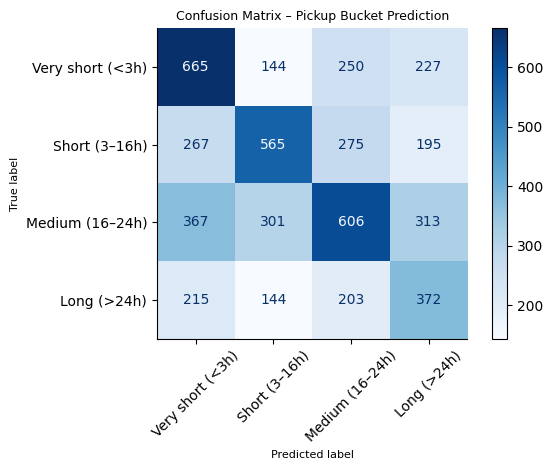

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix – Pickup Bucket Prediction')
plt.tight_layout()
plt.show()

In [ ]:
# Feature Importance on Base Model
rf_model = pipeline_rf.named_steps['classifier']
importances = rf_model.feature_importances_
feature_names = pipeline_rf.named_steps['preprocessor'].get_feature_names_out()

# Sort
indices = np.argsort(importances)[::-1]
# Print importance table
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
print(imp_df)

                                feature  importance
5                num__hours_to_delivery    0.212412
4                        num__year_week    0.161760
0                     num__delivery_day    0.150435
2                    num__delivery_hour    0.134608
3    num__distance_to_borough_center_km    0.104500
1                      num__locker_freq    0.075685
11    cat__delivery_day_of_week_Tuesday    0.021258
12  cat__delivery_day_of_week_Wednesday    0.019437
6      cat__delivery_day_of_week_Friday    0.019425
7      cat__delivery_day_of_week_Monday    0.018440
10   cat__delivery_day_of_week_Thursday    0.017528
17                cat__location_Outdoor    0.016910
16                 cat__location_Indoor    0.014005
13                cat__borough_Brooklyn    0.010306
14               cat__borough_Manhattan    0.009041
8    cat__delivery_day_of_week_Saturday    0.006838
15                  cat__borough_Queens    0.006572
9      cat__delivery_day_of_week_Sunday    0.000841


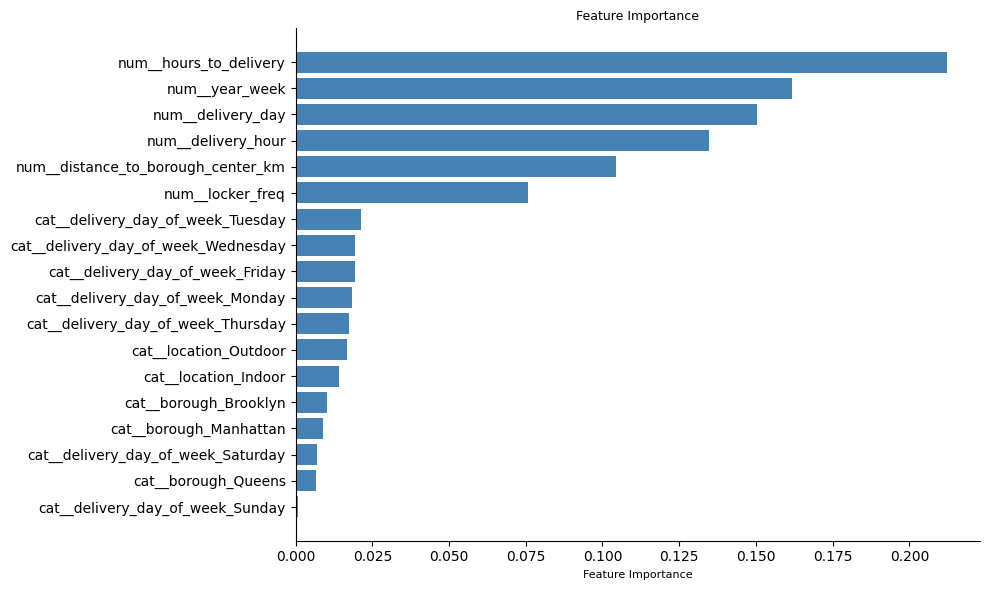

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices], align='center', color='steelblue')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

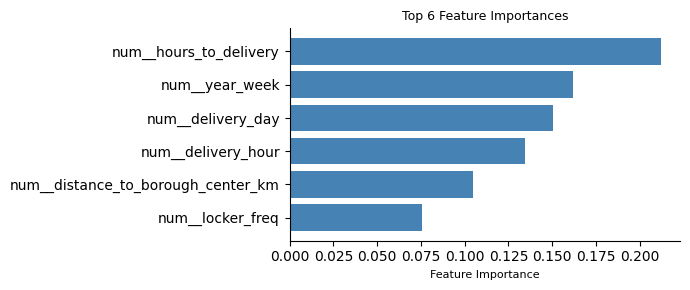

In [ ]:
# Top 6
top_n = 6
top_indices = indices[:top_n]
top_importances = importances[top_indices]
top_feature_names = [feature_names[i] for i in top_indices]

plt.figure(figsize=(7, 3))
plt.barh(range(top_n), top_importances, align='center', color='steelblue')
plt.yticks(range(top_n), top_feature_names)
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Feature Importances')
plt.tight_layout()
plt.show()

### Tuned with Hyperparameters

In [ ]:
start_time = time.time()

# Create Pipeline
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

pipeline_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf_base)])

# Hyperparameters
param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [15, 20, 30],
    'classifier__min_samples_split': [5, 10],
    'classifier__min_samples_leaf': [2, 4],
    'classifier__max_features': ['sqrt', 'log2', 0.3, 0.5]}

random_search = RandomizedSearchCV(
    pipeline_tuned,
    param_distributions=param_dist,
    n_iter=20,               # number of parameter combinations to try
    cv=3,                    # 3-fold cross-validation
    scoring='f1_macro',      # f1_macro for imbalanced classification
    random_state=42,
    n_jobs=-1,
    verbose=1)

print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

print(f"Best parameters found: {random_search.best_params_}")
print(f"Best cross-validation F1-macro score: {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_

# Train and Predict
y_pred_train_tuned = best_model.predict(X_train)
y_pred_test_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)

train_acc_tuned = accuracy_score(y_train, y_pred_train_tuned)
test_acc_tuned = accuracy_score(y_test, y_pred_test_tuned)
train_f1_tuned = f1_score(y_train, y_pred_train_tuned, average='macro')
test_f1_tuned = f1_score(y_test, y_pred_test_tuned, average='macro')

# ROC-AUC
rocauc_tuned = roc_auc_score(
    y_test,
    y_prob_tuned,
    multi_class='ovr',
    average='macro')

# Time
end_time = time.time()
runtime_seconds = end_time - start_time
runtime_minutes = runtime_seconds / 60

Starting hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters found: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 0.3, 'classifier__max_depth': 20}
Best cross-validation F1-macro score: 0.4327


Evaluate

In [ ]:
print(f"\n--- Performance Metrics ---")
print(f"Macro F1-Score: {test_f1_tuned:.4f}")
print(f"Macro ROC-AUC:  {rocauc_tuned:.4f}")
print(f"Test Accuracy:  {test_acc_tuned:.4f}")
print(f"Train Accuracy: {train_acc_tuned:.4f}")
print(f"Runtime:        {runtime_seconds:.2f} seconds ({runtime_minutes:.2f} minutes)")
print(f"\n--- Classification Report ---")
print(classification_report(y_test, y_pred_test_tuned, digits=4))


--- Performance Metrics ---
Macro F1-Score: 0.4508
Macro ROC-AUC:  0.7160
Test Accuracy:  0.4572
Train Accuracy: 0.8259
Runtime:        190.90 seconds (3.18 minutes)

--- Classification Report ---
                  precision    recall  f1-score   support

     Long (>24h)     0.3680    0.3747    0.3714       934
 Medium (16–24h)     0.4758    0.4581    0.4668      1587
   Short (3–16h)     0.4940    0.4708    0.4821      1302
Very short (<3h)     0.4651    0.5023    0.4830      1286

        accuracy                         0.4572      5109
       macro avg     0.4507    0.4515    0.4508      5109
    weighted avg     0.4580    0.4572    0.4573      5109



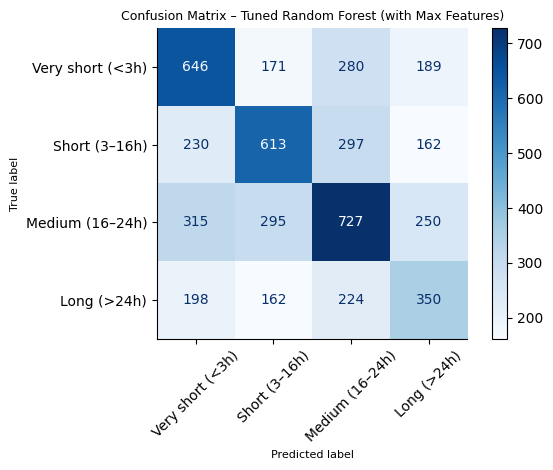

In [ ]:
cm_tuned = confusion_matrix(y_test, y_pred_test_tuned, labels=labels)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=labels)
disp_tuned.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix – Tuned Random Forest (with Max Features)')
plt.tight_layout()
plt.show()

In [ ]:
# Feature importance on tuned model
best_rf = best_model.named_steps['classifier']
importances_tuned = best_rf.feature_importances_
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

imp_df_tuned = pd.DataFrame({'feature': feature_names, 'importance': importances_tuned})
imp_df_tuned = imp_df_tuned.sort_values('importance', ascending=False)

print("\n--- Top 15 Feature Importances (Tuned Model) ---")
print(imp_df_tuned.head(15).to_string(index=False))


--- Top 15 Feature Importances (Tuned Model) ---
                            feature  importance
             num__hours_to_delivery    0.279592
                     num__year_week    0.176212
                  num__delivery_day    0.172360
                 num__delivery_hour    0.101795
 num__distance_to_borough_center_km    0.074676
                   num__locker_freq    0.050888
  cat__delivery_day_of_week_Tuesday    0.022468
cat__delivery_day_of_week_Wednesday    0.021639
   cat__delivery_day_of_week_Monday    0.020236
 cat__delivery_day_of_week_Thursday    0.019850
   cat__delivery_day_of_week_Friday    0.019588
              cat__location_Outdoor    0.009676
              cat__borough_Brooklyn    0.007089
               cat__location_Indoor    0.007085
 cat__delivery_day_of_week_Saturday    0.006881


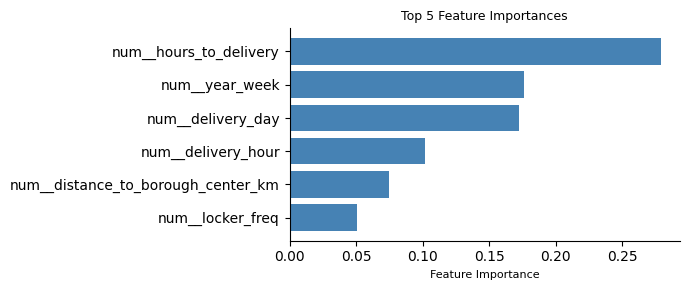

In [ ]:
# Top 6
plt.figure(figsize=(7, 3))
top_features = imp_df_tuned.head(6)
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 5 Feature Importances')
plt.tight_layout()
plt.show()

### Comparison

In [ ]:
# Compare base vs tuned performance
print("\n--- Model Comparison ---")
print(f"{'Metric':<20} {'Base RF':>12} {'Tuned RF':>12} {'Improvement':>12}")
print(f"{'-'*56}")
print(f"{'Macro F1':<20} {test_f1:>12.4f} {test_f1_tuned:>12.4f} {(test_f1_tuned - test_f1):>+12.4f}")
print(f"{'ROC-AUC':<20} {rocauc_base:>12.4f} {rocauc_tuned:>12.4f} {(rocauc_tuned - rocauc_base):>+12.4f}")
print(f"{'Runtime (sec)':<20} {runtime_seconds_base:>12.2f} {runtime_seconds:>12.2f} {(runtime_seconds - runtime_seconds_base):>+12.2f}")


--- Model Comparison ---
Metric                    Base RF     Tuned RF  Improvement
--------------------------------------------------------
Macro F1                   0.4286       0.4508      +0.0222
ROC-AUC                    0.7072       0.7160      +0.0088
Runtime (sec)                2.16       190.90      +188.74


# Neural Network

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

In [ ]:
nn_base = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    alpha=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=SEED
)

In [ ]:
pipeline_nn_base = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("classifier", nn_base)])

In [ ]:
start = time.time()
pipeline_nn_base.fit(X_train, y_train_enc)
base_time = time.time() - start

In [ ]:
y_pred_base = pipeline_nn_base.predict(X_test)
y_prob_base = pipeline_nn_base.predict_proba(X_test)

In [ ]:
# ROC_AUC
rocauc_base = roc_auc_score(
    y_test_enc,
    y_prob_base,
    multi_class="ovr",
    average="macro")

In [ ]:
print(f"Train Accuracy: {pipeline_nn_base.score(X_train, y_train_enc):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test_enc, y_pred_base):.4f}")
print(f"F1-Macro:       {f1_score(y_test_enc, y_pred_base, average='macro'):.4f}")
print(f"ROC-AUC:        {rocauc_base:.4f}")
print(f"Training time:  {base_time:.2f}s")
print("\nClassification Report (Base NN):")
print(classification_report(y_test_enc, y_pred_base, target_names=le.classes_))

Train Accuracy: 0.4338
Test Accuracy:  0.3936
F1-Macro:       0.3692
ROC-AUC:        0.6561
Training time:  11.00s

Classification Report (Base NN):
                  precision    recall  f1-score   support

     Long (>24h)       0.32      0.16      0.21       934
 Medium (16–24h)       0.40      0.43      0.41      1587
   Short (3–16h)       0.41      0.42      0.41      1302
Very short (<3h)       0.40      0.50      0.44      1286

        accuracy                           0.39      5109
       macro avg       0.38      0.38      0.37      5109
    weighted avg       0.39      0.39      0.38      5109



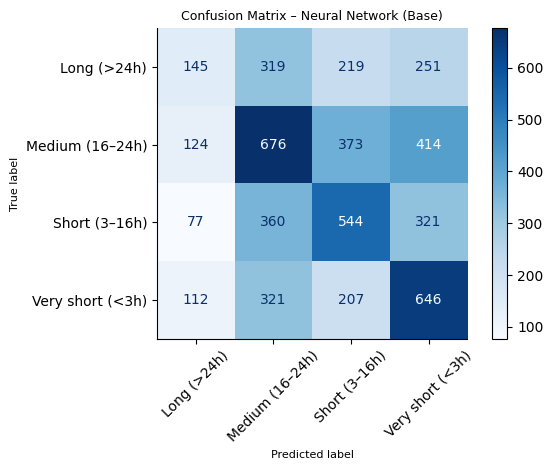

In [ ]:
cm_base = confusion_matrix(y_test_enc, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix – Neural Network (Base)")
plt.tight_layout()
plt.show()

### Hyperparameter Tuning

In [ ]:
nn_tuned = MLPClassifier(
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=SEED)

In [ ]:
pipeline_nn_tuned = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("classifier", nn_tuned)])

In [ ]:
param_dist_nn = {
    "classifier__hidden_layer_sizes": [(64, 32), (128, 64), (256, 128, 64)],
    "classifier__activation":         ["relu", "tanh"],
    "classifier__alpha":              [0.0001, 0.001, 0.01],
    "classifier__max_iter":           [500],
    "classifier__n_iter_no_change":   [10, 20],}

In [ ]:
nn_search = RandomizedSearchCV(
    pipeline_nn_tuned,
    param_distributions=param_dist_nn,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42,
    n_jobs=1,
    verbose=1)

In [ ]:
start = time.time()
nn_search.fit(X_train, y_train_enc)
tuned_time = time.time() - start

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
pipeline_nn_tuned_best = nn_search.best_estimator_
print(f"Best parameters: {nn_search.best_params_}")

Best parameters: {'classifier__n_iter_no_change': 20, 'classifier__max_iter': 500, 'classifier__hidden_layer_sizes': (256, 128, 64), 'classifier__alpha': 0.01, 'classifier__activation': 'tanh'}


In [ ]:
y_pred_tuned = pipeline_nn_tuned_best.predict(X_test)
y_prob_tuned = pipeline_nn_tuned_best.predict_proba(X_test)

In [ ]:
rocauc_tuned = roc_auc_score(
    y_test_enc,
    y_prob_tuned,
    multi_class="ovr",
    average="macro")

In [ ]:
print(f"\nTrain Accuracy: {pipeline_nn_tuned_best.score(X_train, y_train_enc):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test_enc, y_pred_tuned):.4f}")
print(f"F1-Macro:       {f1_score(y_test_enc, y_pred_tuned, average='macro'):.4f}")
print(f"ROC-AUC:        {rocauc_tuned:.4f}")
print(f"Training time:  {tuned_time:.2f}s")
print("\nClassification Report (Tuned NN):")
print(classification_report(y_test_enc, y_pred_tuned, target_names=le.classes_))


Train Accuracy: 0.5346
Test Accuracy:  0.3991
F1-Macro:       0.3826
ROC-AUC:        0.6639
Training time:  718.67s

Classification Report (Tuned NN):
                  precision    recall  f1-score   support

     Long (>24h)       0.33      0.22      0.26       934
 Medium (16–24h)       0.41      0.47      0.43      1587
   Short (3–16h)       0.43      0.40      0.41      1302
Very short (<3h)       0.39      0.45      0.42      1286

        accuracy                           0.40      5109
       macro avg       0.39      0.38      0.38      5109
    weighted avg       0.40      0.40      0.39      5109



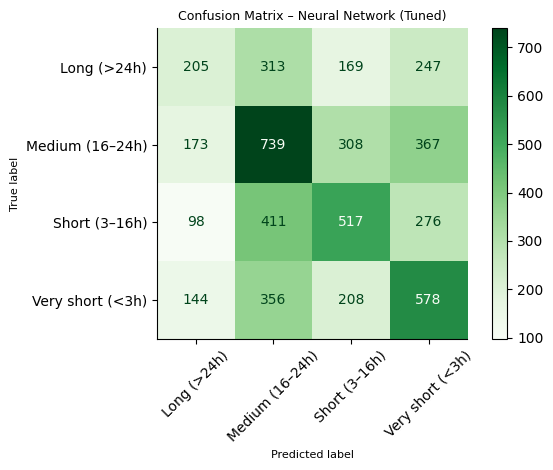

In [ ]:
cm_tuned = confusion_matrix(y_test_enc, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=le.classes_)
disp.plot(cmap="Greens", xticks_rotation=45)
plt.title("Confusion Matrix – Neural Network (Tuned)")
plt.tight_layout()
plt.show()

In [ ]:
# Summary table
print("=" * 65)
print(f"{'Model':<25} {'Test Acc':>9} {'F1-macro':>9} {'ROC-AUC':>9} {'Time':>9}")
print("=" * 65)
print(f"{'Base NN (64,32)':<25} {accuracy_score(y_test_enc, y_pred_base):>9.4f} {f1_score(y_test_enc, y_pred_base, average='macro'):>9.4f} {rocauc_base:>9.4f} {base_time:>8.0f}s")
print(f"{'Tuned NN':<25} {accuracy_score(y_test_enc, y_pred_tuned):>9.4f} {f1_score(y_test_enc, y_pred_tuned, average='macro'):>9.4f} {rocauc_tuned:>9.4f} {tuned_time:>8.0f}s")
print("=" * 65)

Model                      Test Acc  F1-macro   ROC-AUC      Time
Base NN (64,32)              0.3936    0.3692    0.6561       11s
Tuned NN                     0.3991    0.3826    0.6639      719s
